## 기본 실행

### 라이브러리 임포트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 데이터
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt

### 기본 설정

In [3]:
# 무제한으로 모든 컬럼 표시
pd.set_option('display.max_columns', None)
# 출력 폭을 넉넉하게 설정
pd.set_option('display.width', 2000)
# 행 제한 해제
pd.set_option('display.max_rows', None)

### 데이터 로드

In [4]:
!rsync -ah --progress "/content/drive/MyDrive/공모전/Toss/toss/train.parquet" "/content/train.parquet"
!rsync -ah --progress "/content/drive/MyDrive/공모전/Toss/toss/test.parquet"  "/content/test.parquet"

train_data = pd.read_parquet('/content/train.parquet')
test_data  = pd.read_parquet('/content/test.parquet')

sending incremental file list
train.parquet
          8.79G 100%   70.59MB/s    0:01:58 (xfr#1, to-chk=0/1)
sending incremental file list
test.parquet
          1.28G 100%   68.18MB/s    0:00:17 (xfr#1, to-chk=0/1)


## EDA

### 데이터 확인

In [5]:
# 데이터 로드 확인
print('train_data:', train_data.shape)
print('test_data:', test_data.shape)

train_data: (10704179, 119)
test_data: (1527298, 119)


In [6]:
# 빠른 스냅샷
print('columns count:', len(train_data.columns))
print('train_data sample:', train_data.columns.tolist()[:10], '\n')

print('train_data head:'"\n", train_data.head(), '\n')
print('test_data head:'"\n", test_data.head(), '\n')

columns count: 119
train_data sample: ['gender', 'age_group', 'inventory_id', 'day_of_week', 'hour', 'seq', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4'] 

train_data head:
   gender age_group inventory_id day_of_week hour                                                seq  l_feat_1  l_feat_2  l_feat_3  l_feat_4  l_feat_5  l_feat_6  l_feat_7  l_feat_8  l_feat_9  l_feat_10  l_feat_11  l_feat_12  l_feat_13  l_feat_14  l_feat_15  l_feat_16  l_feat_17  l_feat_18  l_feat_19  l_feat_20  l_feat_21  l_feat_22  l_feat_23  l_feat_24  l_feat_25  l_feat_26  l_feat_27   feat_e_1     feat_e_2   feat_e_3  feat_e_4  feat_e_5  feat_e_6  feat_e_7    feat_e_8   feat_e_9   feat_e_10  feat_d_1  feat_d_2  feat_d_3   feat_d_4  feat_d_5  feat_d_6   feat_c_1  feat_c_2   feat_c_3   feat_c_4   feat_c_5  feat_c_6   feat_c_7   feat_c_8  feat_b_1  feat_b_2   feat_b_3  feat_b_4   feat_b_5     feat_b_6  feat_a_1  feat_a_2  feat_a_3  feat_a_4  feat_a_5  feat_a_6  feat_a_7  feat_a_8  feat_a_9  feat_a_10  feat_a_11  f

### 결측치 확인

In [7]:
# train_data info
print('train_data info:"\n"', train_data.info())

# 결측치 종합
print('train missing values sum:', train_data.isnull().sum().sum())

# 결측치 컬럼별 종합
print('train missing values:'"\n", train_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10704179 entries, 0 to 10704178
Columns: 119 entries, gender to clicked
dtypes: float32(112), int32(1), object(6)
memory usage: 5.0+ GB
train_data info:"
" None
train missing values sum: 2745337
train missing values:
 gender            17208
age_group         17208
inventory_id          0
day_of_week           0
hour                  0
seq                   0
l_feat_1              0
l_feat_2          17208
l_feat_3              0
l_feat_4              0
l_feat_5              0
l_feat_6              0
l_feat_7              0
l_feat_8          17208
l_feat_9              0
l_feat_10             0
l_feat_11             0
l_feat_12             0
l_feat_13             0
l_feat_14             0
l_feat_15             0
l_feat_16             0
l_feat_17             0
l_feat_18         17208
l_feat_19         17208
l_feat_20         17208
l_feat_21         17208
l_feat_22         17208
l_feat_23         17208
l_feat_24         17208
l_feat_25   

In [8]:
# 총 결측치 비율
total_missing = train_data.isnull().sum().sum()
total_cells = train_data.shape[0] * train_data.shape[1]
print('missing ratio:',total_missing/total_cells*100)

# 높은 결측치 비율 컬럼
missing_pct = train_data.isnull().mean()*100
print('missing ratio top 67'"\n",
      missing_pct.sort_values(ascending=False).head(10))

missing ratio: 0.215523851231649
missing ratio top 67
 feat_e_3     10.141432
feat_a_3      0.173745
feat_a_4      0.173745
feat_a_5      0.173745
feat_a_6      0.173745
feat_a_18     0.173745
feat_a_17     0.173745
feat_a_9      0.173745
feat_a_10     0.173745
feat_a_11     0.173745
dtype: float64


In [9]:
# 결측이 여러 컬럼에서 동일한 row에 발생하는지 확인
cols = ['gender', 'age_group', 'feat_e_1', 'feat_e_2']
missing_df = train_data[cols].isna()

# 컬럼별 결측 row 수 확인
print('missing_count')
print(missing_df.sum())

# diff_count가 0인 경우 두 컬럼의 결측 위치가 동일함
for i, col1 in enumerate(cols):
    for col2 in cols[i + 1:]:
        diff_count = (missing_df[col1] != missing_df[col2]).sum()
        print(f"{col1} vs {col2}: {diff_count:,}")

missing_count
gender       17208
age_group    17208
feat_e_1     17208
feat_e_2     17208
dtype: int64
gender vs age_group: 0
gender vs feat_e_1: 0
gender vs feat_e_2: 0
age_group vs feat_e_1: 0
age_group vs feat_e_2: 0
feat_e_1 vs feat_e_2: 0


### 기초 통계 확인

In [10]:
# 숫자형 컬럼 통계 요약
print('숫자형 컬럼 통계 요약'"\n", train_data.describe())

숫자형 컬럼 통계 요약
            l_feat_1      l_feat_2      l_feat_3      l_feat_4      l_feat_5      l_feat_6      l_feat_7      l_feat_8      l_feat_9     l_feat_10     l_feat_11     l_feat_12     l_feat_13     l_feat_14     l_feat_15     l_feat_16     l_feat_17     l_feat_18     l_feat_19   l_feat_20     l_feat_21     l_feat_22   l_feat_23     l_feat_24     l_feat_25     l_feat_26     l_feat_27      feat_e_1      feat_e_2      feat_e_3      feat_e_4      feat_e_5      feat_e_6      feat_e_7      feat_e_8      feat_e_9     feat_e_10      feat_d_1      feat_d_2      feat_d_3      feat_d_4      feat_d_5      feat_d_6      feat_c_1      feat_c_2      feat_c_3      feat_c_4      feat_c_5      feat_c_6      feat_c_7      feat_c_8      feat_b_1      feat_b_2      feat_b_3      feat_b_4      feat_b_5      feat_b_6      feat_a_1      feat_a_2      feat_a_3      feat_a_4      feat_a_5      feat_a_6      feat_a_7      feat_a_8      feat_a_9     feat_a_10     feat_a_11     feat_a_12     feat_a_13     

In [11]:
# object(범주형) 컬럼 통계 요약
cat_col = train_data.select_dtypes(include=['object']).columns.tolist()
cat_col= train_data.select_dtypes(include=['object']).columns.tolist()
print('벙주형 변수 통계 요약'"\n", train_data[cat_col].describe())

벙주형 변수 통계 요약
           gender age_group inventory_id day_of_week      hour       seq
count   10686971  10686971     10704179    10704179  10704179  10704179
unique         2         8           18           7        24   7179942
top          1.0       7.0            2           2        08       144
freq     6713514   3706802      2630473     1532022    755311     20142


In [12]:
# 범주형 변수별 빈도 상위 5개 값 확인
for col in cat_col:
    print(f'{col}')
    print(train_data[col].value_counts().head(5),'\n')

gender
gender
1.0    6713514
2.0    3973457
Name: count, dtype: int64 

age_group
age_group
7.0    3706802
8.0    2646736
6.0    2320895
5.0     591501
4.0     554070
Name: count, dtype: int64 

inventory_id
inventory_id
2     2630473
36    1518438
37    1396465
29    1015710
42    1013762
Name: count, dtype: int64 

day_of_week
day_of_week
2    1532022
4    1530297
6    1530282
3    1529921
5    1529839
Name: count, dtype: int64 

hour
hour
08    755311
12    607775
07    603023
09    587434
20    584545
Name: count, dtype: int64 

seq
seq
144          20142
321          10940
519           8033
479           6059
57,479,35     4637
Name: count, dtype: int64 



### 히스토그램

In [13]:
# 시각화
def plot_hist_scan(
    df,
    exclude_cols=None,
    q_low=0.001,
    q_high=0.999,
    bins=200,
    sample_n=1000000,
    seed=42
):
    if exclude_cols is None:
        exclude_cols = [
            'clicked',
            'seq',
            'gender',
            'age_group',
            'inventory_id',
            'day_of_week',
            'hour'
        ]

    # 범주형/타겟/seq 제외 후 수치형 컬럼 자동 선택
    cols = []

    for col in df.columns:
        if col in exclude_cols:
            continue

        s = pd.to_numeric(df[col], errors='coerce')

        if s.notna().sum() == 0:
            continue

        cols.append(col)

    print(f'hist cols: {len(cols)}')
    print(cols)

    rng = np.random.RandomState(seed)

    for col in cols:
        s = pd.to_numeric(df[col], errors='coerce')
        x = s.dropna().astype('float32').values

        if x.size == 0:
            continue

        # 너무 크면 샘플링
        if x.size > sample_n:
            idx = rng.choice(x.size, sample_n, replace=False)
            x = x[idx]

        lo, hi = np.quantile(x, [q_low, q_high])
        x_cap = np.clip(x, lo, hi)

        fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

        # 원본 분포
        axes[0].hist(x, bins=bins)
        axes[0].set_title(f'{col} raw')
        axes[0].set_yscale('log')
        axes[0].ticklabel_format(axis='x', style='plain', useOffset=False)

        # 극단값 클리핑 후 분포
        axes[1].hist(x_cap, bins=bins)
        axes[1].set_title(f'{col} clipped')
        axes[1].set_yscale('log')
        axes[1].ticklabel_format(axis='x', style='plain', useOffset=False)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

        tail_lo = int((x < lo).sum())
        tail_hi = int((x > hi).sum())
        uniq = int(np.unique(x).size)
        zero_pct = float((x == 0).mean()) if np.any(x == 0) else 0.0
        skew = float(pd.Series(x).skew())
        kurt = float(pd.Series(x).kurt())

        print(
            f'[{col}] n={x.size:,} uniq={uniq:,} zero%={zero_pct * 100:.2f}% | '
            f'<lo:{tail_lo:,} >hi:{tail_hi:,} | '
            f'lo={lo:.4g} hi={hi:.4g} | '
            f'skew={skew:.3f} kurt={kurt:.3f}'
        )

        xs = np.sort(x)
        print('  min 5:', xs[:5])
        print('  max 5:', xs[-5:][::-1])

hist cols: 112
['l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4', 'l_feat_5', 'l_feat_6', 'l_feat_7', 'l_feat_8', 'l_feat_9', 'l_feat_10', 'l_feat_11', 'l_feat_12', 'l_feat_13', 'l_feat_14', 'l_feat_15', 'l_feat_16', 'l_feat_17', 'l_feat_18', 'l_feat_19', 'l_feat_20', 'l_feat_21', 'l_feat_22', 'l_feat_23', 'l_feat_24', 'l_feat_25', 'l_feat_26', 'l_feat_27', 'feat_e_1', 'feat_e_2', 'feat_e_3', 'feat_e_4', 'feat_e_5', 'feat_e_6', 'feat_e_7', 'feat_e_8', 'feat_e_9', 'feat_e_10', 'feat_d_1', 'feat_d_2', 'feat_d_3', 'feat_d_4', 'feat_d_5', 'feat_d_6', 'feat_c_1', 'feat_c_2', 'feat_c_3', 'feat_c_4', 'feat_c_5', 'feat_c_6', 'feat_c_7', 'feat_c_8', 'feat_b_1', 'feat_b_2', 'feat_b_3', 'feat_b_4', 'feat_b_5', 'feat_b_6', 'feat_a_1', 'feat_a_2', 'feat_a_3', 'feat_a_4', 'feat_a_5', 'feat_a_6', 'feat_a_7', 'feat_a_8', 'feat_a_9', 'feat_a_10', 'feat_a_11', 'feat_a_12', 'feat_a_13', 'feat_a_14', 'feat_a_15', 'feat_a_16', 'feat_a_17', 'feat_a_18', 'history_a_1', 'history_a_2', 'history_a_3', 'history_a_

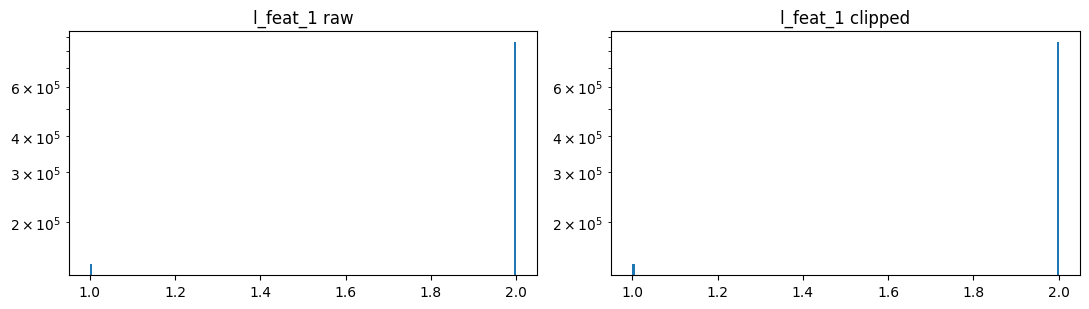

[l_feat_1] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=-2.054 kurt=2.220
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


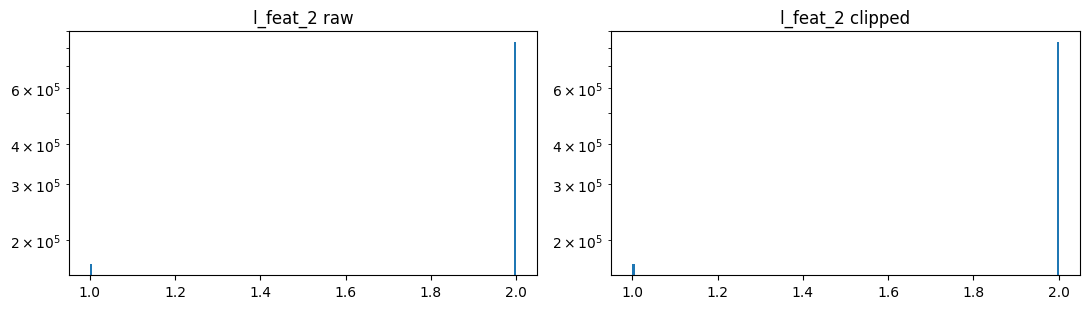

[l_feat_2] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=-1.773 kurt=1.144
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


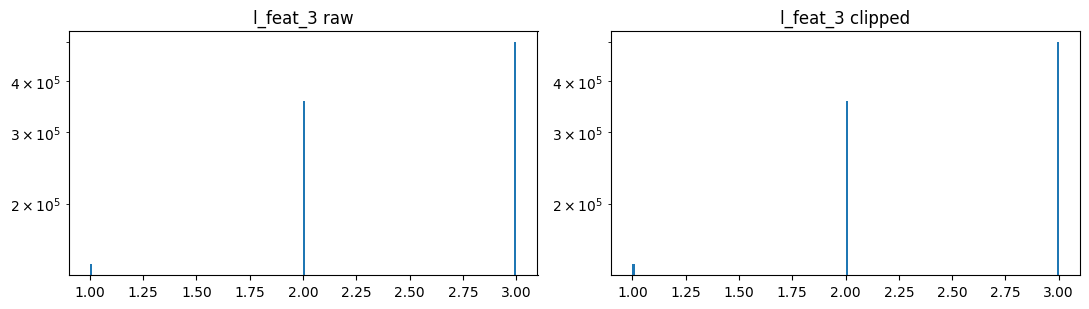

[l_feat_3] n=1,000,000 uniq=3 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=3 | skew=-0.649 kurt=-0.827
  min 5: [1. 1. 1. 1. 1.]
  max 5: [3. 3. 3. 3. 3.]


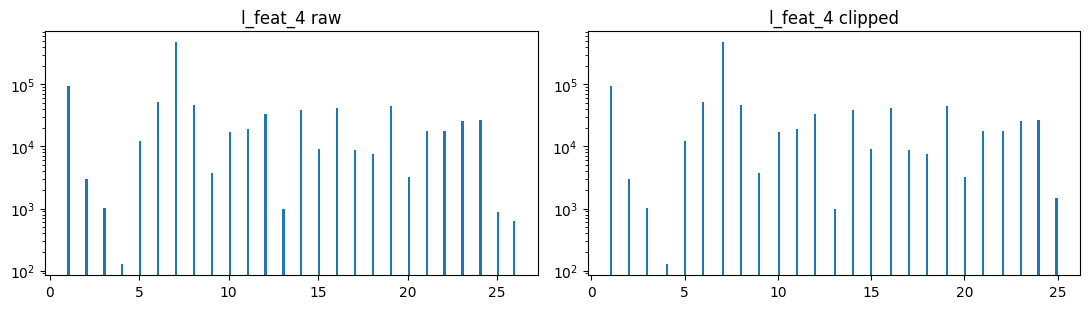

[l_feat_4] n=1,000,000 uniq=26 zero%=0.00% | <lo:0 >hi:623 | lo=1 hi=25 | skew=0.968 kurt=0.160
  min 5: [1. 1. 1. 1. 1.]
  max 5: [26. 26. 26. 26. 26.]


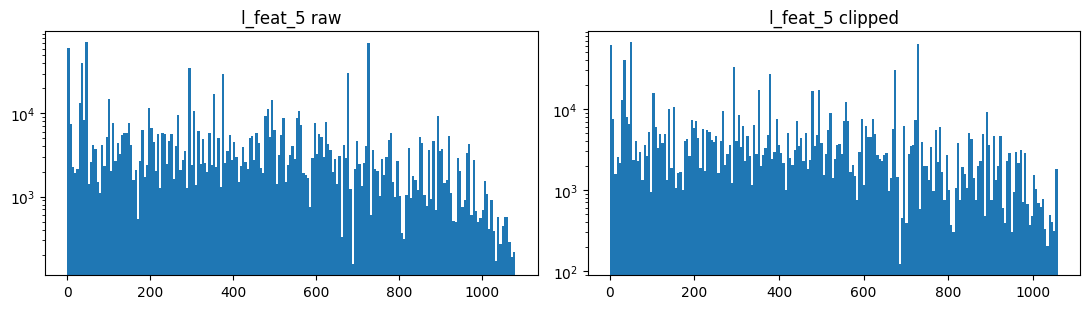

[l_feat_5] n=1,000,000 uniq=1,074 zero%=0.00% | <lo:0 >hi:772 | lo=1 hi=1058 | skew=0.258 kurt=-1.115
  min 5: [1. 1. 1. 1. 1.]
  max 5: [1079. 1078. 1077. 1077. 1077.]


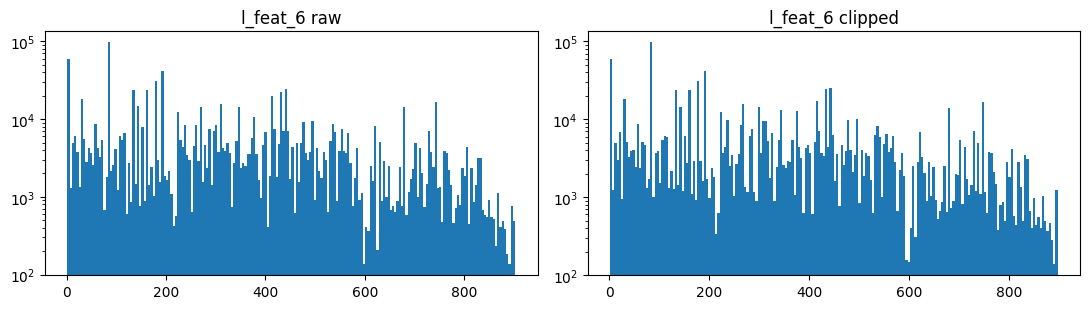

[l_feat_6] n=1,000,000 uniq=897 zero%=0.00% | <lo:0 >hi:586 | lo=1 hi=897 | skew=0.529 kurt=-0.737
  min 5: [1. 1. 1. 1. 1.]
  max 5: [903. 903. 903. 903. 903.]


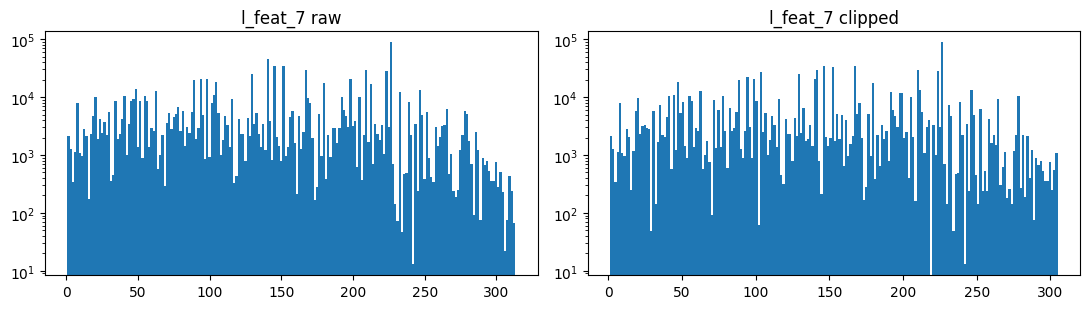

[l_feat_7] n=1,000,000 uniq=312 zero%=0.00% | <lo:0 >hi:839 | lo=1 hi=305 | skew=-0.115 kurt=-0.991
  min 5: [1. 1. 1. 1. 1.]
  max 5: [313. 313. 313. 313. 313.]


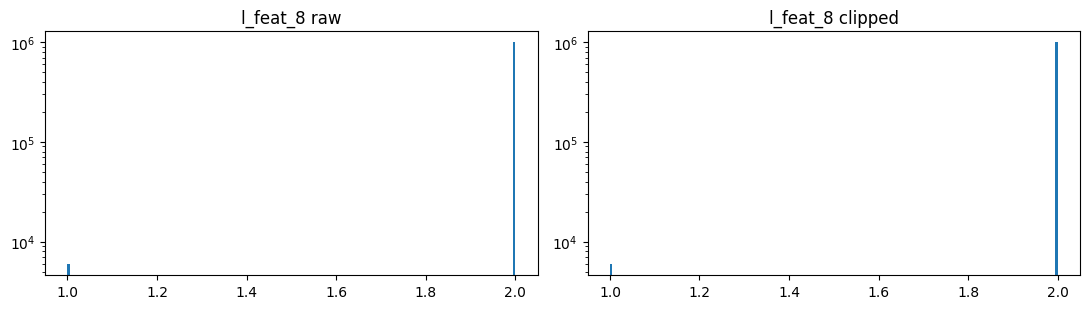

[l_feat_8] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=-12.855 kurt=163.244
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


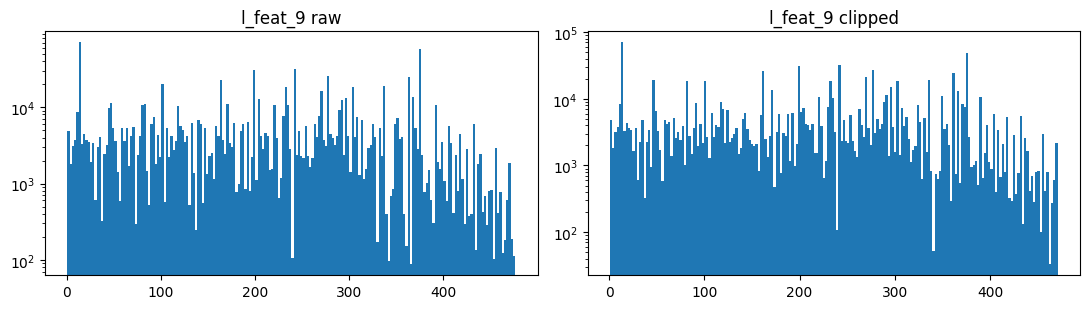

[l_feat_9] n=1,000,000 uniq=475 zero%=0.00% | <lo:0 >hi:300 | lo=1 hi=471 | skew=-0.090 kurt=-1.116
  min 5: [1. 1. 1. 1. 1.]
  max 5: [476. 476. 476. 476. 476.]


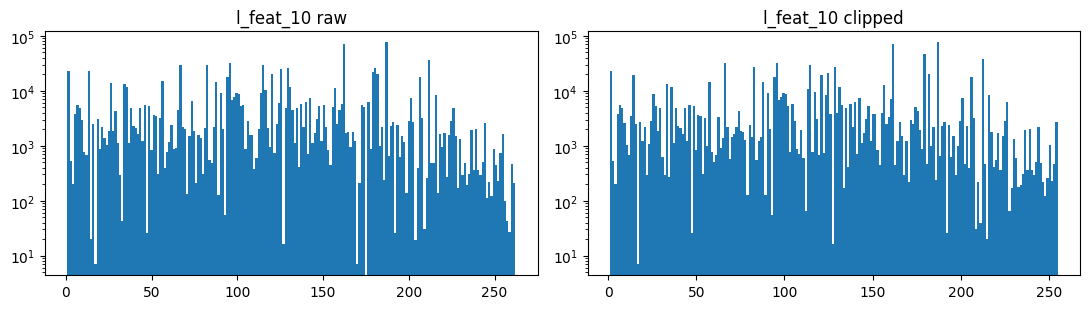

[l_feat_10] n=1,000,000 uniq=260 zero%=0.00% | <lo:0 >hi:848 | lo=1 hi=255 | skew=-0.239 kurt=-0.884
  min 5: [1. 1. 1. 1. 1.]
  max 5: [262. 262. 262. 262. 262.]


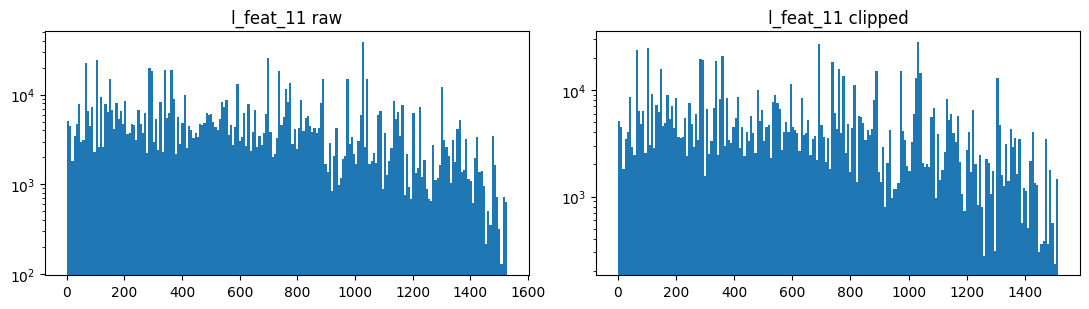

[l_feat_11] n=1,000,000 uniq=1,521 zero%=0.00% | <lo:0 >hi:905 | lo=1 hi=1514 | skew=0.262 kurt=-1.002
  min 5: [1. 1. 1. 1. 1.]
  max 5: [1527. 1526. 1526. 1526. 1526.]


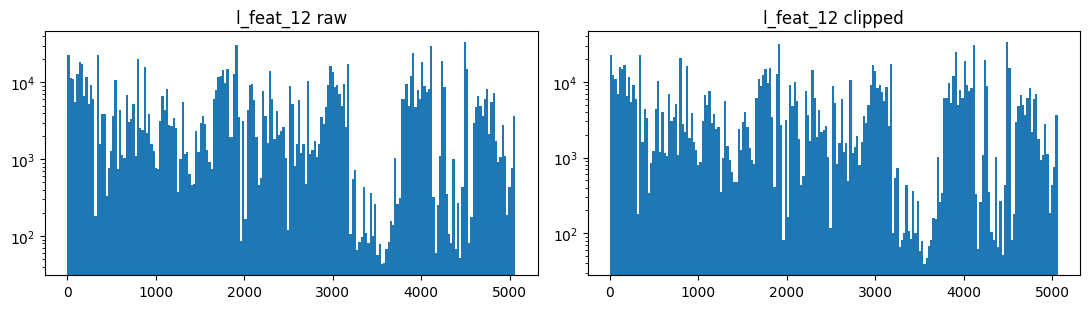

[l_feat_12] n=1,000,000 uniq=4,812 zero%=0.00% | <lo:491 >hi:0 | lo=3 hi=5061 | skew=0.020 kurt=-1.310
  min 5: [1. 1. 1. 1. 1.]
  max 5: [5061. 5061. 5061. 5061. 5061.]


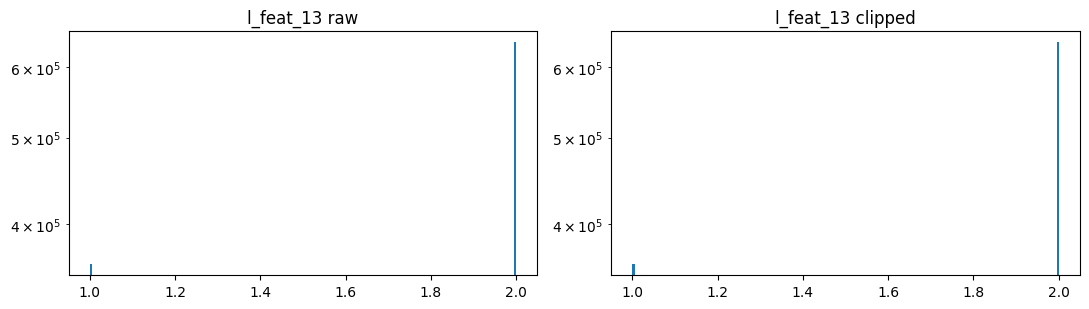

[l_feat_13] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=-0.579 kurt=-1.665
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


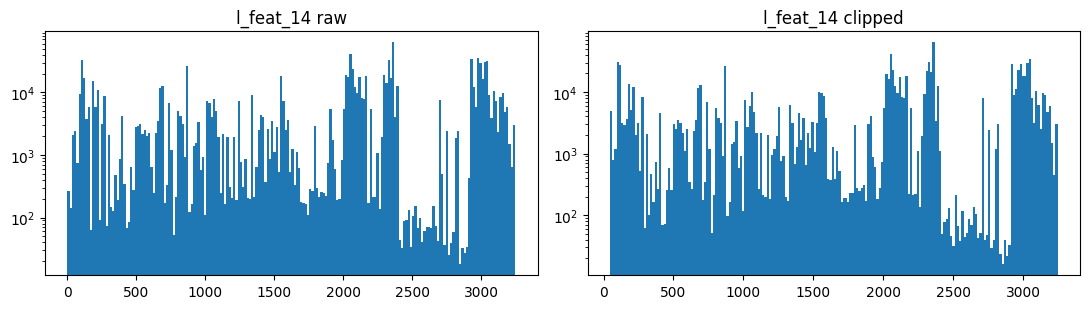

[l_feat_14] n=1,000,000 uniq=3,083 zero%=0.00% | <lo:588 >hi:0 | lo=46 hi=3245 | skew=-0.514 kurt=-0.977
  min 5: [1. 1. 1. 1. 1.]
  max 5: [3245. 3245. 3245. 3245. 3245.]


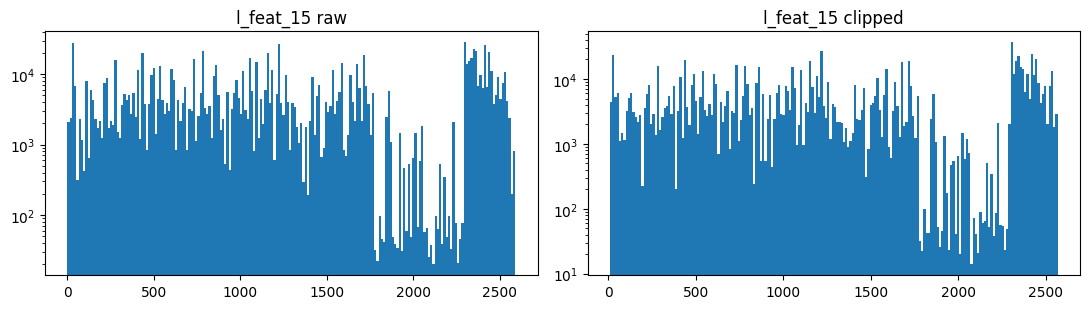

[l_feat_15] n=1,000,000 uniq=2,435 zero%=0.00% | <lo:234 >hi:972 | lo=9 hi=2568 | skew=0.158 kurt=-1.252
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2590. 2590. 2590. 2590. 2590.]


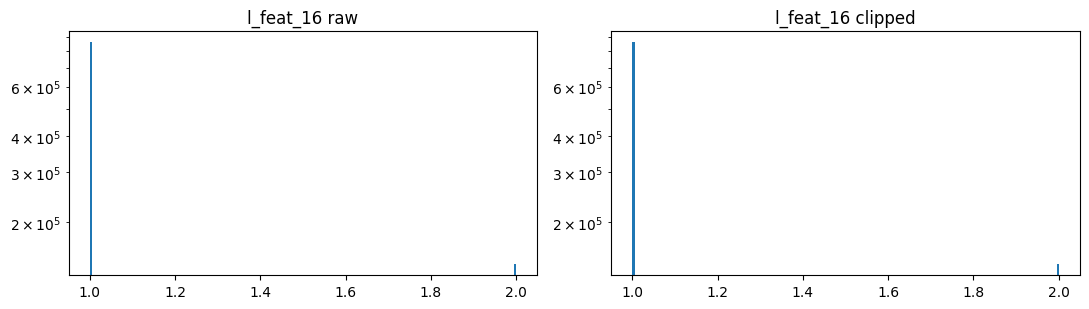

[l_feat_16] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=2.053 kurt=2.215
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


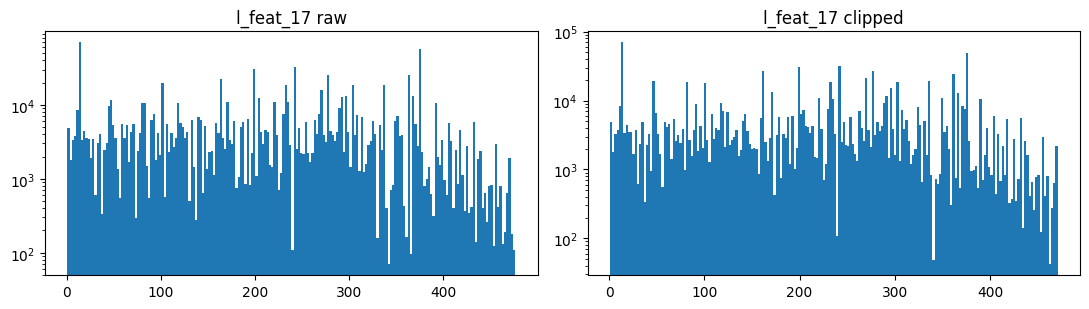

[l_feat_17] n=1,000,000 uniq=476 zero%=0.00% | <lo:0 >hi:289 | lo=1 hi=471 | skew=-0.090 kurt=-1.115
  min 5: [1. 1. 1. 1. 1.]
  max 5: [476. 476. 476. 476. 476.]


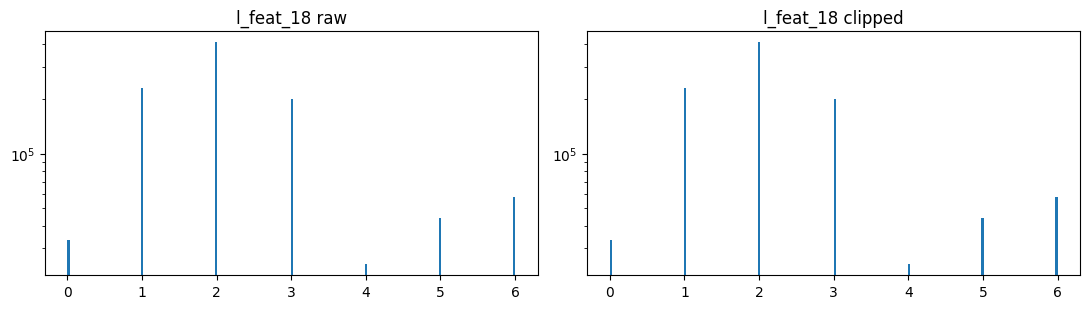

[l_feat_18] n=1,000,000 uniq=7 zero%=3.36% | <lo:0 >hi:0 | lo=0 hi=6 | skew=1.149 kurt=1.185
  min 5: [0. 0. 0. 0. 0.]
  max 5: [6. 6. 6. 6. 6.]


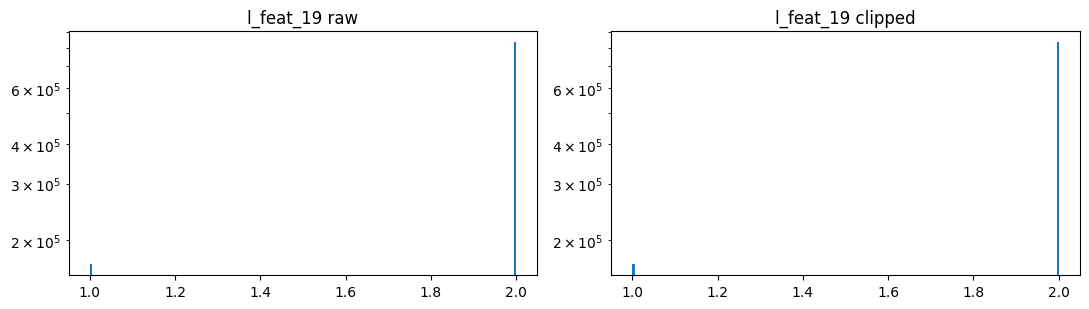

[l_feat_19] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=-1.779 kurt=1.166
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


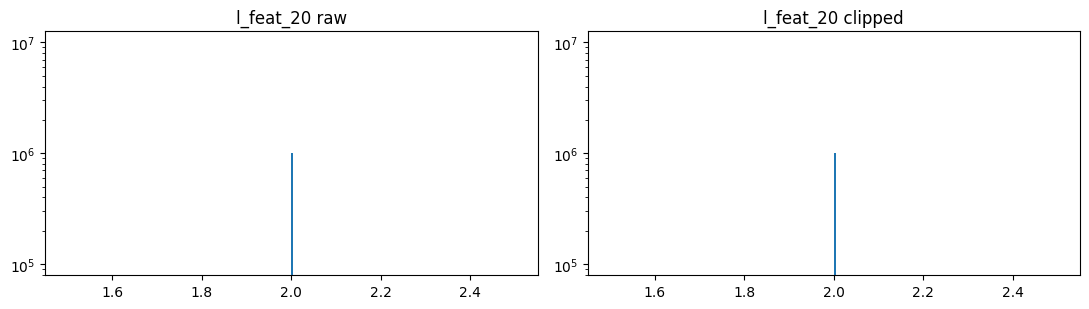

[l_feat_20] n=1,000,000 uniq=1 zero%=0.00% | <lo:0 >hi:0 | lo=2 hi=2 | skew=0.000 kurt=0.000
  min 5: [2. 2. 2. 2. 2.]
  max 5: [2. 2. 2. 2. 2.]


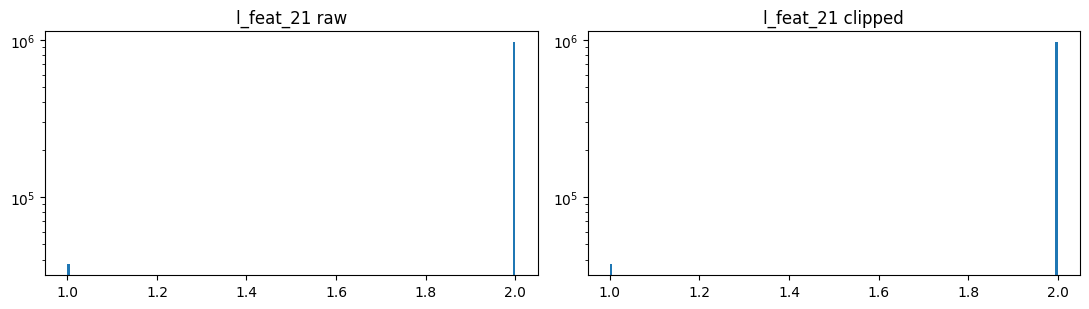

[l_feat_21] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=-4.877 kurt=21.788
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


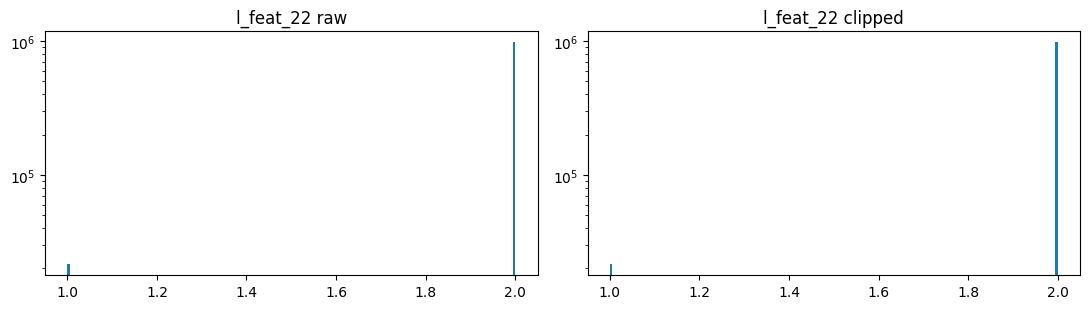

[l_feat_22] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=2 | skew=-6.602 kurt=41.581
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


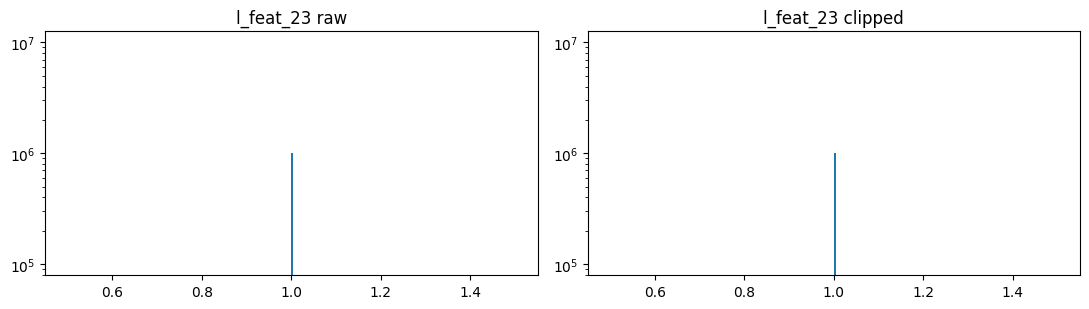

[l_feat_23] n=1,000,000 uniq=1 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=1 | skew=0.000 kurt=0.000
  min 5: [1. 1. 1. 1. 1.]
  max 5: [1. 1. 1. 1. 1.]


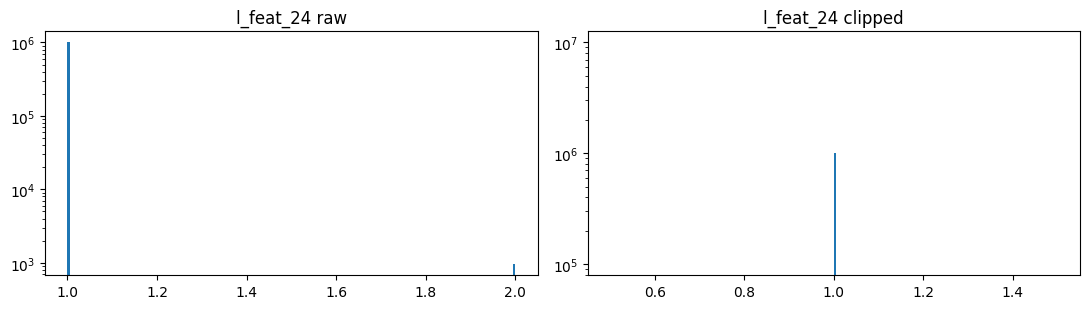

[l_feat_24] n=1,000,000 uniq=2 zero%=0.00% | <lo:0 >hi:958 | lo=1 hi=1 | skew=32.262 kurt=1038.847
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2. 2. 2. 2. 2.]


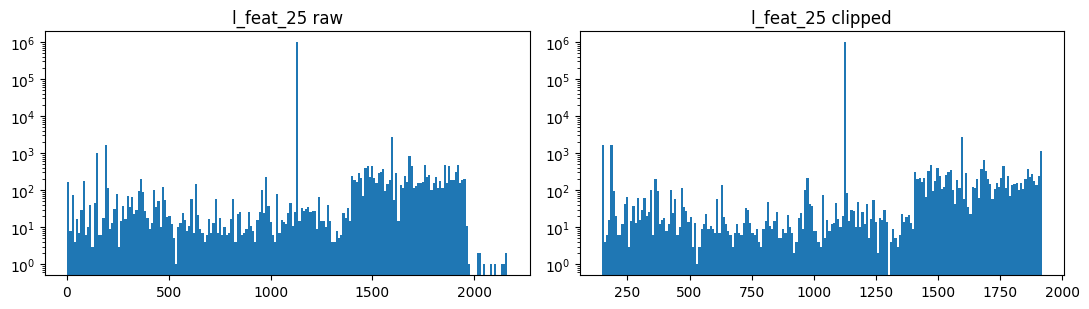

[l_feat_25] n=1,000,000 uniq=1,056 zero%=0.00% | <lo:597 >hi:985 | lo=146 hi=1919 | skew=-1.332 kurt=68.910
  min 5: [1. 1. 1. 1. 1.]
  max 5: [2163. 2163. 2151. 2135. 2100.]


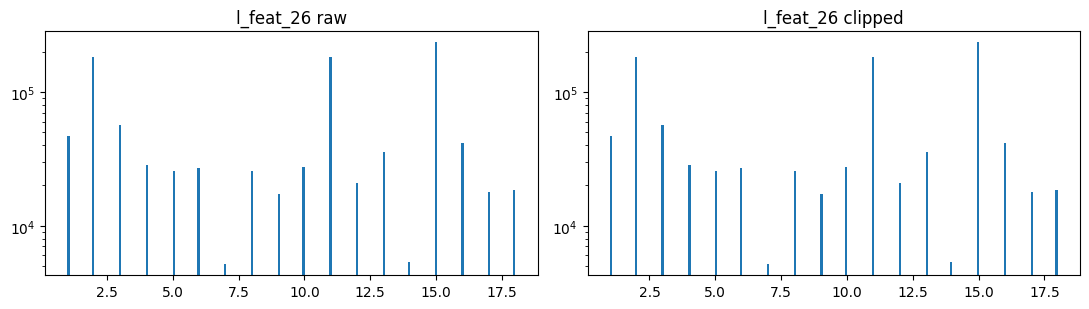

[l_feat_26] n=1,000,000 uniq=18 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=18 | skew=-0.228 kurt=-1.483
  min 5: [1. 1. 1. 1. 1.]
  max 5: [18. 18. 18. 18. 18.]


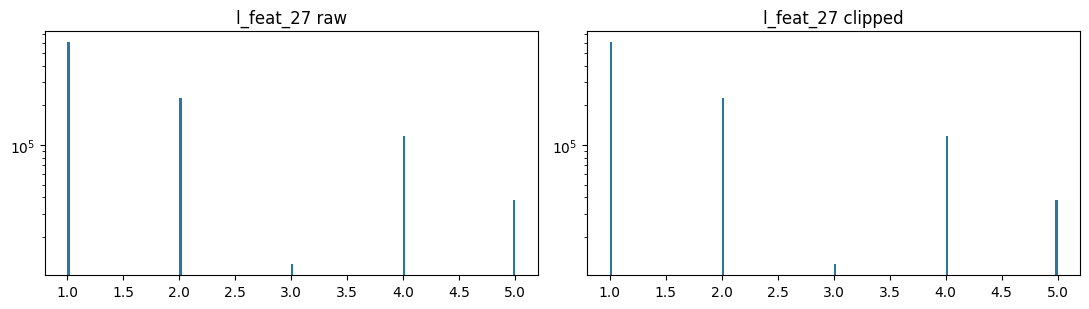

[l_feat_27] n=1,000,000 uniq=5 zero%=0.00% | <lo:0 >hi:0 | lo=1 hi=5 | skew=1.486 kurt=0.939
  min 5: [1. 1. 1. 1. 1.]
  max 5: [5. 5. 5. 5. 5.]


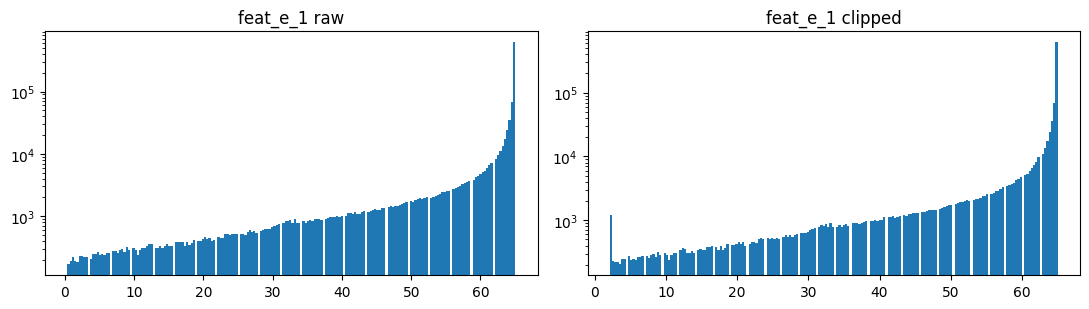

[feat_e_1] n=1,000,000 uniq=180 zero%=0.00% | <lo:958 >hi:0 | lo=2.167 hi=65 | skew=-3.404 kurt=12.161
  min 5: [0.3611111 0.3611111 0.3611111 0.3611111 0.3611111]
  max 5: [65. 65. 65. 65. 65.]


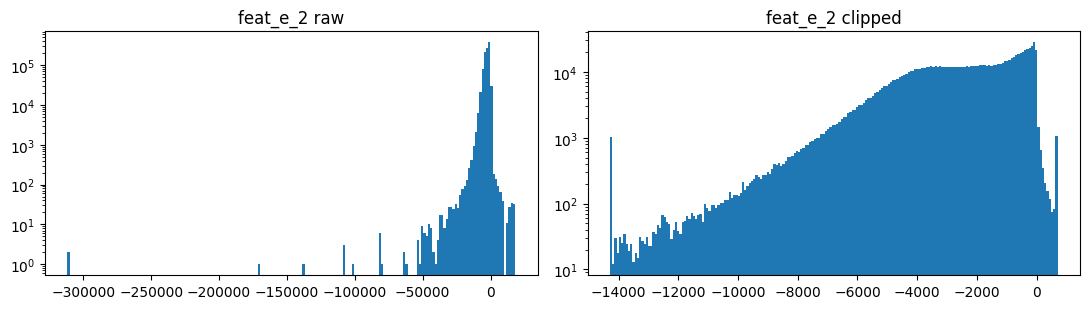

[feat_e_2] n=1,000,000 uniq=331,839 zero%=0.03% | <lo:1,000 >hi:1,000 | lo=-1.429e+04 hi=702.8 | skew=-8.980 kurt=924.858
  min 5: [-311604.25 -310716.03 -170600.23 -138075.23 -107910.96]
  max 5: [18073.945 18073.945 18073.945 18073.945 18073.945]


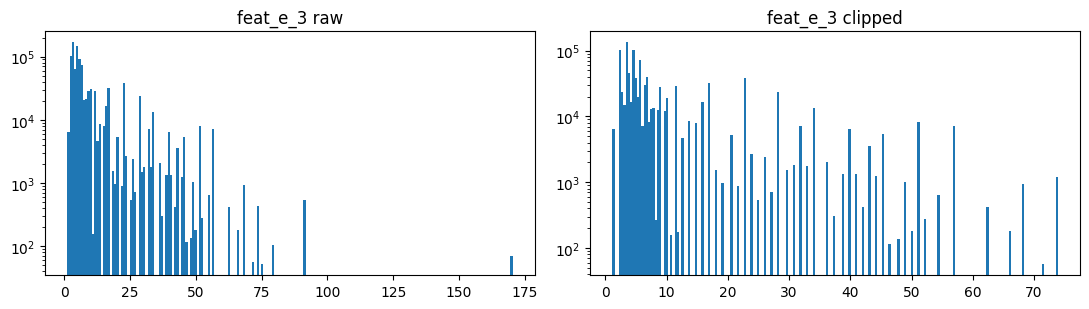

[feat_e_3] n=1,000,000 uniq=105 zero%=0.00% | <lo:0 >hi:770 | lo=1.136 hi=73.86 | skew=2.657 kurt=9.844
  min 5: [1.1363636 1.1363636 1.1363636 1.1363636 1.1363636]
  max 5: [170.45454 170.45454 170.45454 170.45454 170.45454]


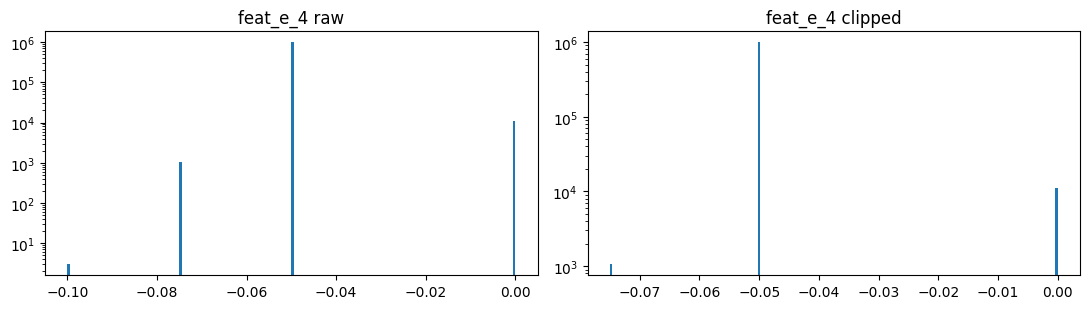

[feat_e_4] n=1,000,000 uniq=4 zero%=1.12% | <lo:3 >hi:0 | lo=-0.075 hi=0 | skew=8.851 kurt=80.952
  min 5: [-0.1   -0.1   -0.1   -0.075 -0.075]
  max 5: [0. 0. 0. 0. 0.]


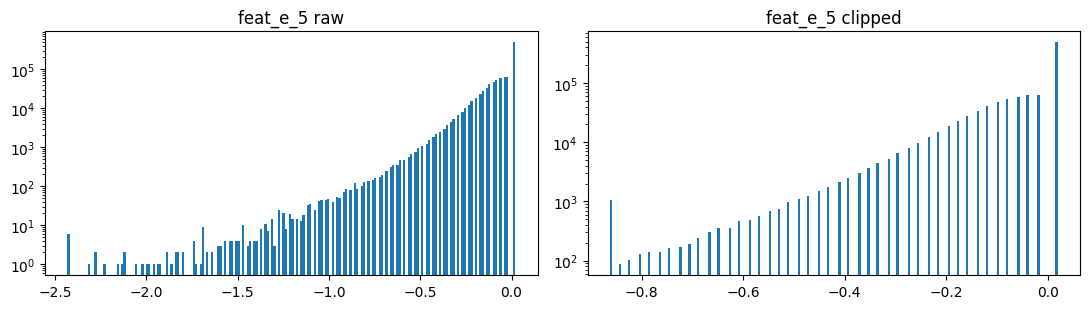

[feat_e_5] n=1,000,000 uniq=108 zero%=0.00% | <lo:921 >hi:0 | lo=-0.8627 hi=0.01961 | skew=-2.820 kurt=16.738
  min 5: [-2.4313726 -2.4313726 -2.4313726 -2.4313726 -2.4313726]
  max 5: [0.01960784 0.01960784 0.01960784 0.01960784 0.01960784]


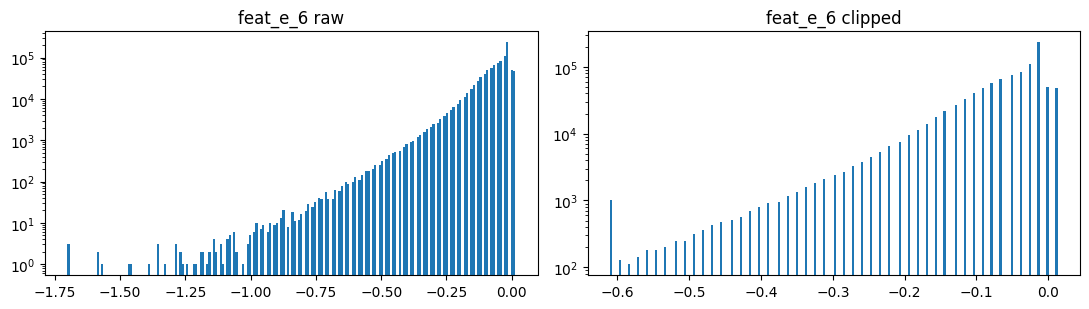

[feat_e_6] n=1,000,000 uniq=107 zero%=4.95% | <lo:926 >hi:0 | lo=-0.6104 hi=0.01299 | skew=-2.779 kurt=15.013
  min 5: [-1.7012987 -1.7012987 -1.7012987 -1.5844156 -1.5844156]
  max 5: [0.01298701 0.01298701 0.01298701 0.01298701 0.01298701]


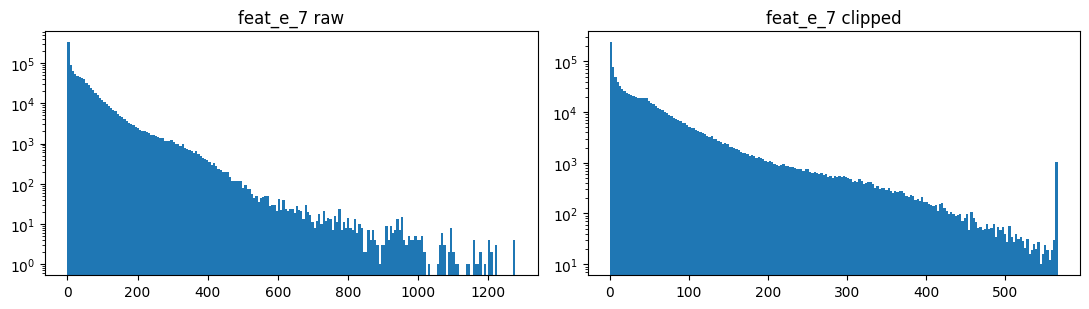

[feat_e_7] n=1,000,000 uniq=8,913 zero%=0.88% | <lo:11 >hi:1,000 | lo=0 hi=566.2 | skew=3.457 kurt=19.951
  min 5: [-0.0625 -0.0625 -0.0625 -0.0625 -0.0625]
  max 5: [1277.375  1277.375  1277.375  1277.375  1225.6875]


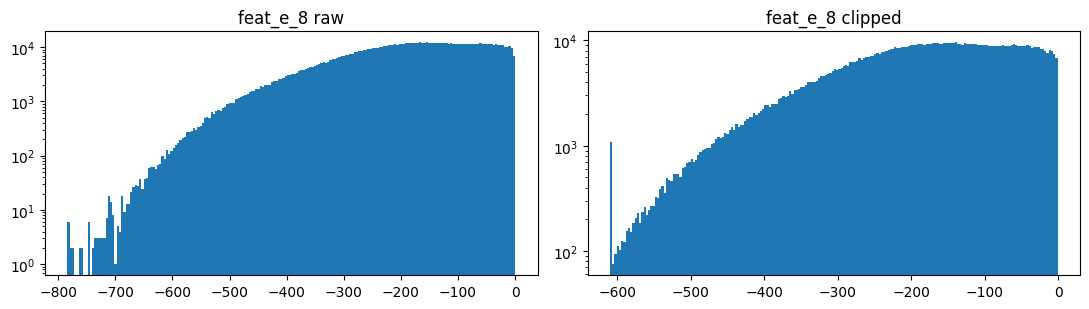

[feat_e_8] n=1,000,000 uniq=27,168 zero%=0.00% | <lo:1,000 >hi:967 | lo=-609.8 hi=-0.8 | skew=-0.649 kurt=0.015
  min 5: [-783.75555 -783.75555 -783.75555 -783.75555 -783.57776]
  max 5: [0.02222222 0.02222222 0.02222222 0.02222222 0.02222222]


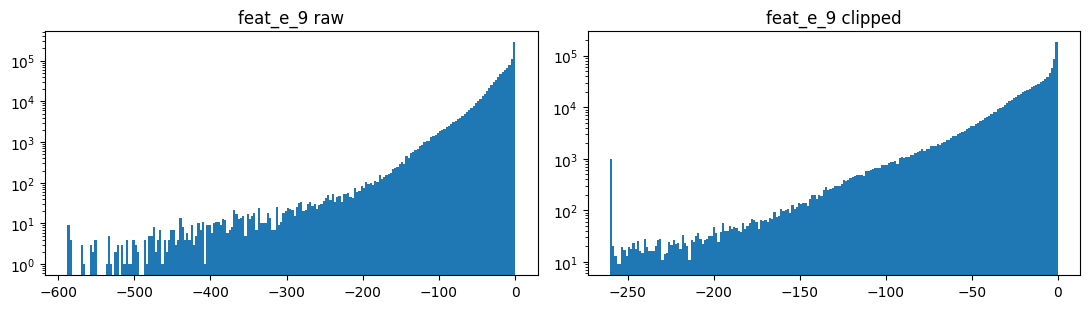

[feat_e_9] n=1,000,000 uniq=16,918 zero%=0.14% | <lo:1,000 >hi:9 | lo=-260.4 hi=0 | skew=-4.285 kurt=38.118
  min 5: [-587.6774 -587.6774 -587.6774 -587.6774 -587.6774]
  max 5: [0.01075269 0.01075269 0.01075269 0.01075269 0.01075269]


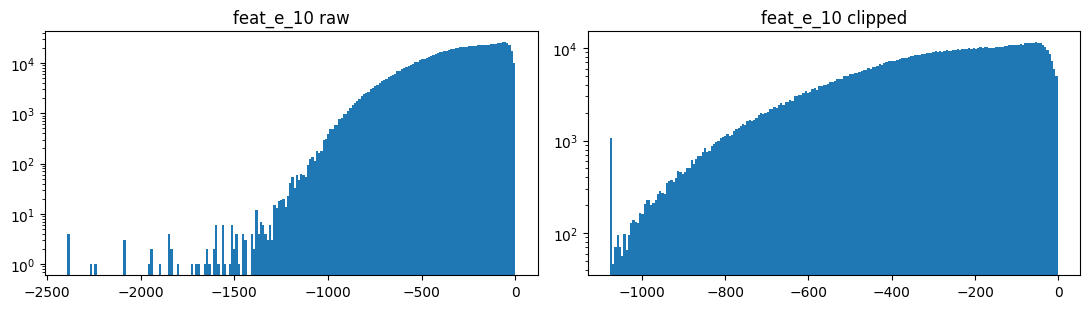

[feat_e_10] n=1,000,000 uniq=67,089 zero%=0.00% | <lo:1,000 >hi:996 | lo=-1076 hi=-2.057 | skew=-0.802 kurt=0.338
  min 5: [-2391.9429 -2391.9429 -2391.9429 -2391.9429 -2264.1   ]
  max 5: [0.01428571 0.01428571 0.01428571 0.01428571 0.01428571]


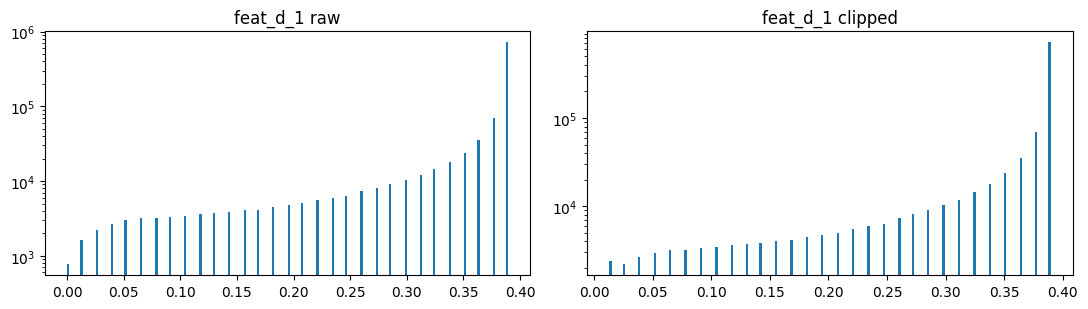

[feat_d_1] n=1,000,000 uniq=31 zero%=0.08% | <lo:771 >hi:0 | lo=0.01299 hi=0.3896 | skew=-3.114 kurt=9.578
  min 5: [0. 0. 0. 0. 0.]
  max 5: [0.38961038 0.38961038 0.38961038 0.38961038 0.38961038]


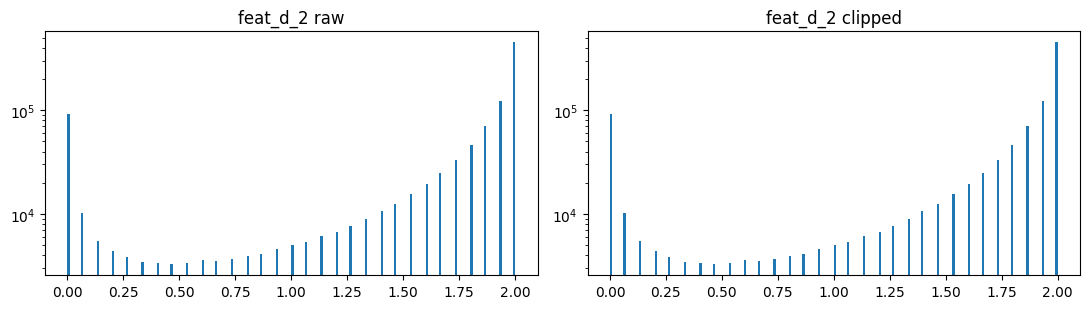

[feat_d_2] n=1,000,000 uniq=31 zero%=9.24% | <lo:0 >hi:0 | lo=0 hi=2 | skew=-1.738 kurt=1.465
  min 5: [0. 0. 0. 0. 0.]
  max 5: [2. 2. 2. 2. 2.]


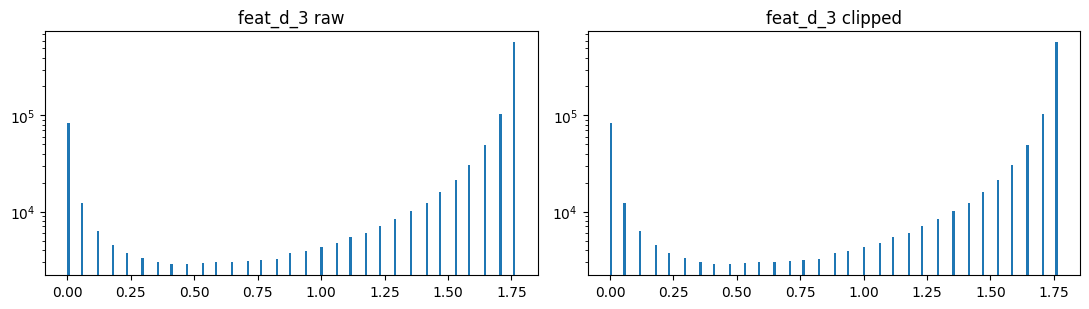

[feat_d_3] n=1,000,000 uniq=31 zero%=8.26% | <lo:0 >hi:0 | lo=0 hi=1.765 | skew=-1.935 kurt=2.122
  min 5: [0. 0. 0. 0. 0.]
  max 5: [1.7647059 1.7647059 1.7647059 1.7647059 1.7647059]


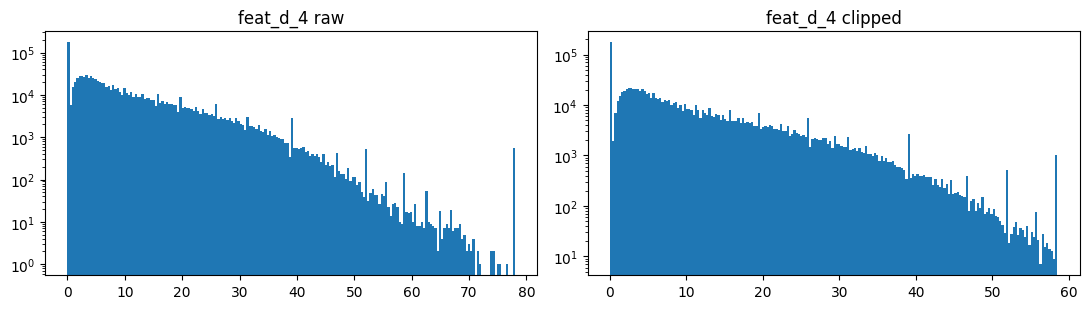

[feat_d_4] n=1,000,000 uniq=43,770 zero%=17.35% | <lo:0 >hi:889 | lo=0 hi=58.5 | skew=1.570 kurt=3.132
  min 5: [0. 0. 0. 0. 0.]
  max 5: [78. 78. 78. 78. 78.]


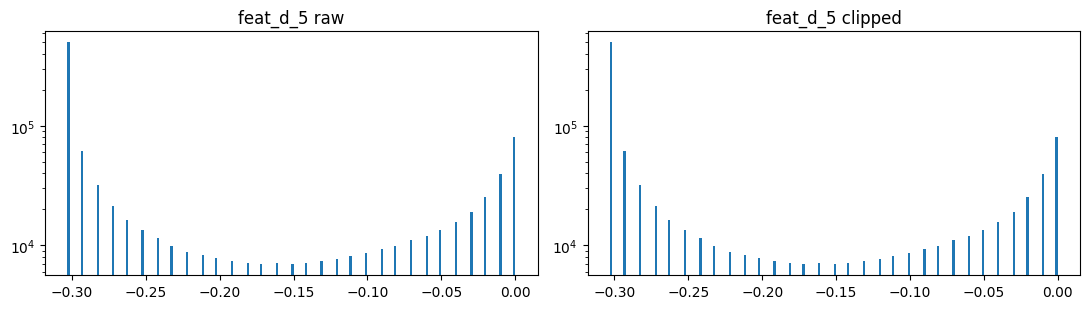

[feat_d_5] n=1,000,000 uniq=31 zero%=8.12% | <lo:0 >hi:0 | lo=-0.303 hi=0 | skew=0.955 kurt=-0.841
  min 5: [-0.3030303 -0.3030303 -0.3030303 -0.3030303 -0.3030303]
  max 5: [0. 0. 0. 0. 0.]


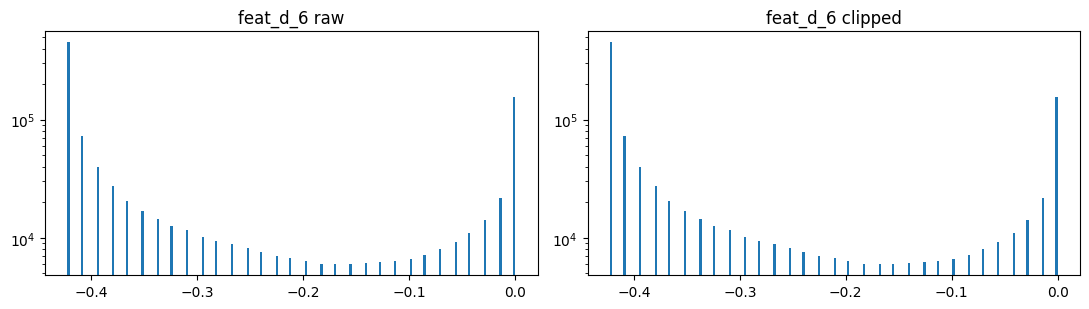

[feat_d_6] n=1,000,000 uniq=31 zero%=15.43% | <lo:0 >hi:0 | lo=-0.4225 hi=0 | skew=0.931 kurt=-0.900
  min 5: [-0.4225352 -0.4225352 -0.4225352 -0.4225352 -0.4225352]
  max 5: [0. 0. 0. 0. 0.]


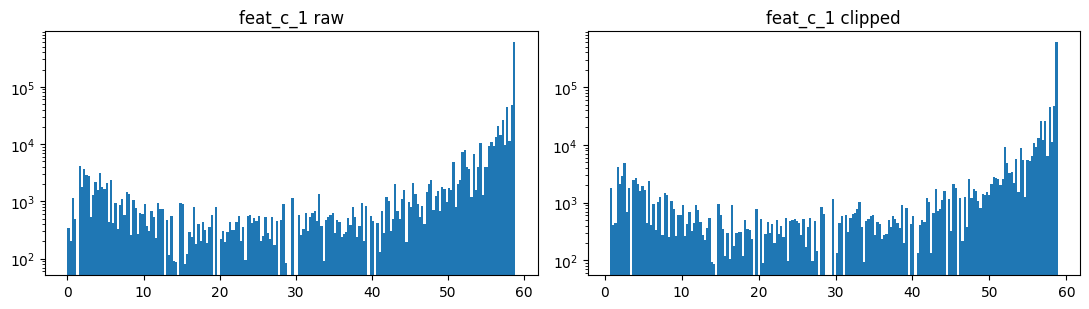

[feat_c_1] n=1,000,000 uniq=490 zero%=0.03% | <lo:840 >hi:0 | lo=0.7039 hi=58.85 | skew=-3.080 kurt=8.362
  min 5: [0. 0. 0. 0. 0.]
  max 5: [58.849396 58.849396 58.849396 58.849396 58.849396]


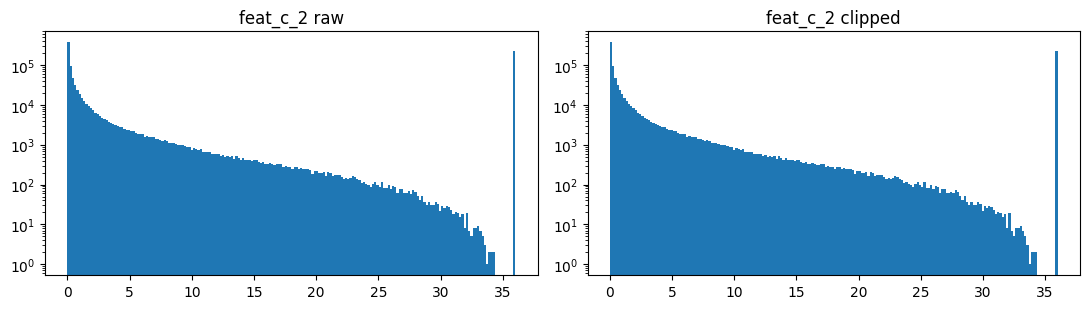

[feat_c_2] n=1,000,000 uniq=647,129 zero%=9.92% | <lo:0 >hi:936 | lo=0 hi=36 | skew=1.217 kurt=-0.426
  min 5: [0. 0. 0. 0. 0.]
  max 5: [35.999992 35.999992 35.999992 35.999992 35.999992]


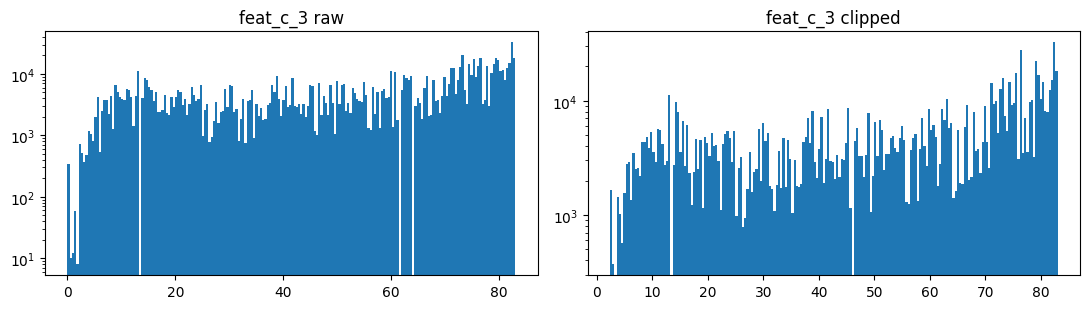

[feat_c_3] n=1,000,000 uniq=662 zero%=0.03% | <lo:476 >hi:0 | lo=2.393 hi=83 | skew=-0.472 kurt=-1.153
  min 5: [0. 0. 0. 0. 0.]
  max 5: [83. 83. 83. 83. 83.]


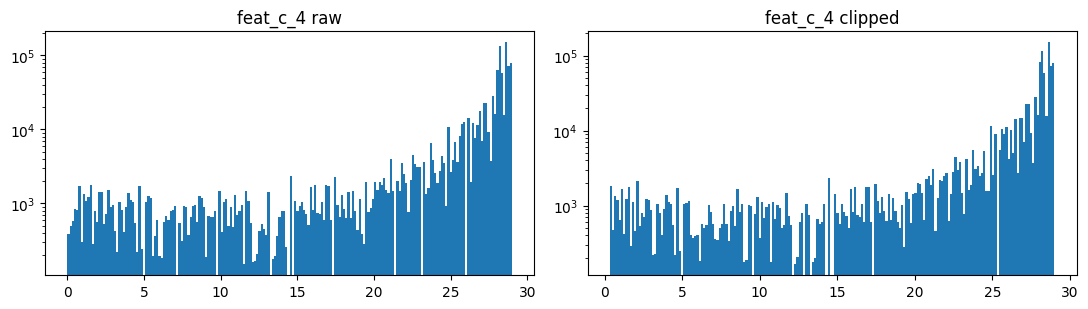

[feat_c_4] n=1,000,000 uniq=552 zero%=0.04% | <lo:889 >hi:0 | lo=0.333 hi=29 | skew=-2.658 kurt=6.458
  min 5: [0. 0. 0. 0. 0.]
  max 5: [29. 29. 29. 29. 29.]


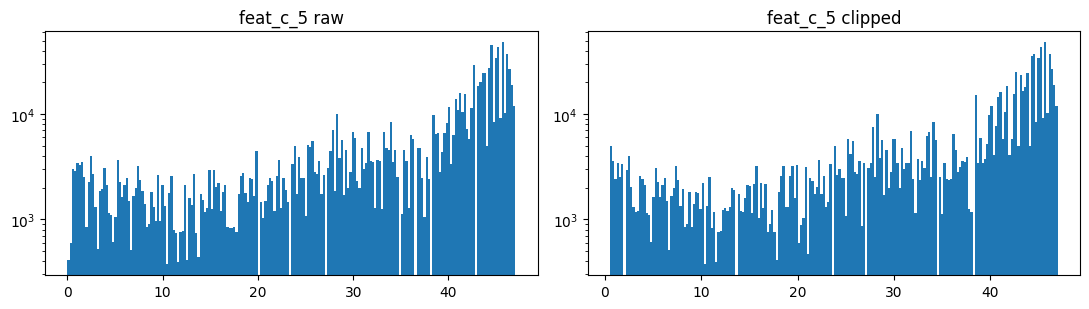

[feat_c_5] n=1,000,000 uniq=630 zero%=0.03% | <lo:999 >hi:0 | lo=0.5263 hi=47 | skew=-1.253 kurt=0.460
  min 5: [0. 0. 0. 0. 0.]
  max 5: [47. 47. 47. 47. 47.]


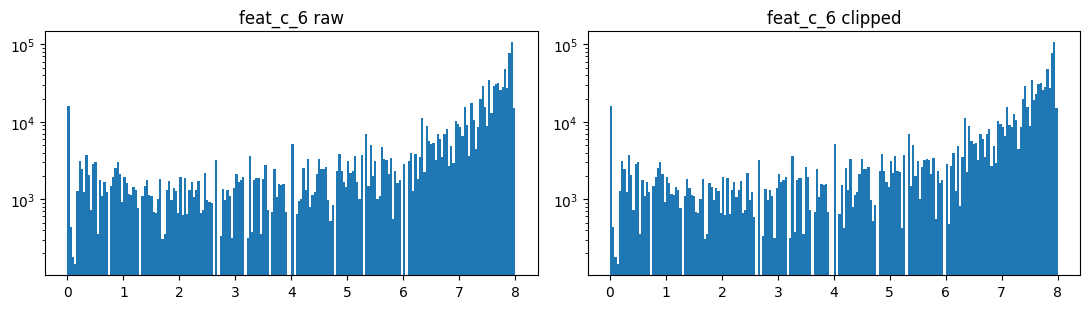

[feat_c_6] n=1,000,000 uniq=493 zero%=1.48% | <lo:0 >hi:0 | lo=0 hi=8 | skew=-1.661 kurt=1.602
  min 5: [0. 0. 0. 0. 0.]
  max 5: [8. 8. 8. 8. 8.]


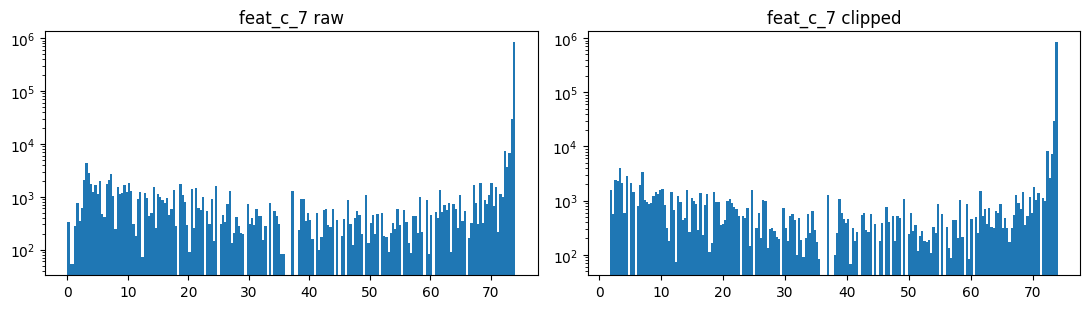

[feat_c_7] n=1,000,000 uniq=435 zero%=0.03% | <lo:792 >hi:0 | lo=1.762 hi=74 | skew=-3.086 kurt=8.038
  min 5: [0. 0. 0. 0. 0.]
  max 5: [74. 74. 74. 74. 74.]


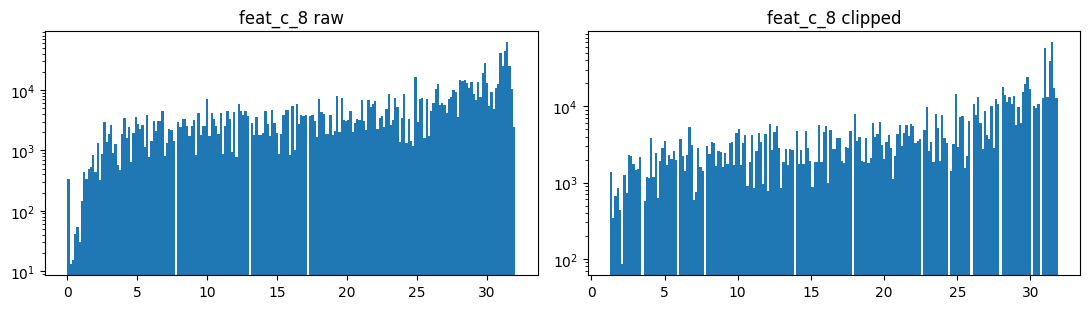

[feat_c_8] n=1,000,000 uniq=637 zero%=0.03% | <lo:869 >hi:731 | lo=1.271 hi=31.85 | skew=-0.880 kurt=-0.450
  min 5: [0. 0. 0. 0. 0.]
  max 5: [32. 32. 32. 32. 32.]


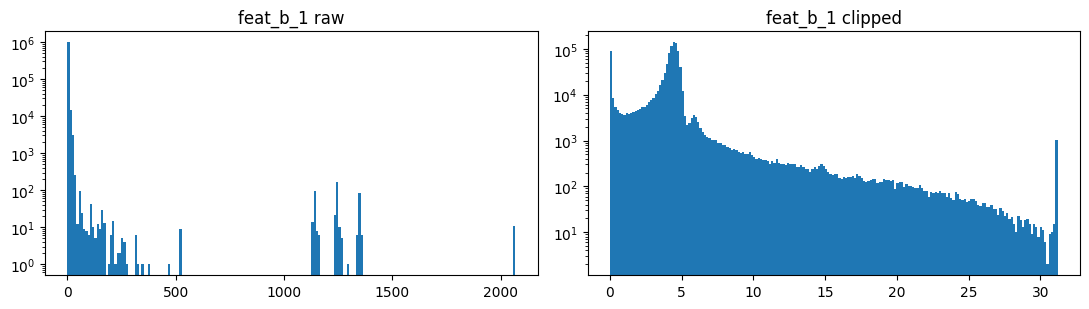

[feat_b_1] n=1,000,000 uniq=3,582 zero%=6.30% | <lo:0 >hi:1,000 | lo=0 hi=31.21 | skew=48.242 kurt=2428.393
  min 5: [0. 0. 0. 0. 0.]
  max 5: [2066.103 2066.103 2066.103 2066.103 2065.763]


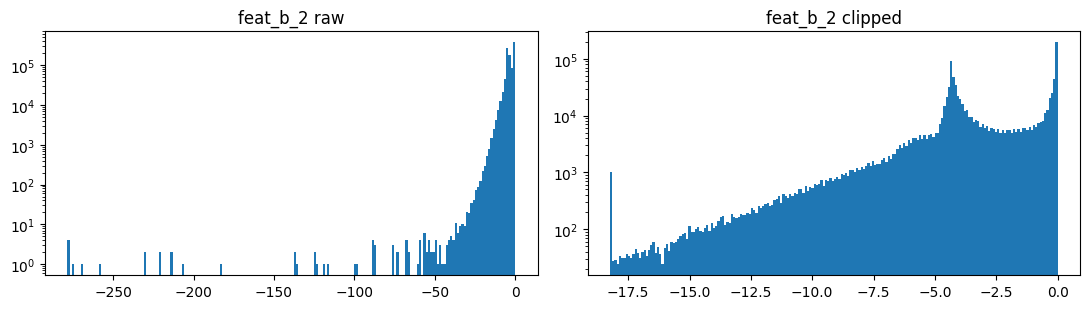

[feat_b_2] n=1,000,000 uniq=2,061 zero%=7.20% | <lo:1,000 >hi:0 | lo=-18.24 hi=0 | skew=-11.837 kurt=894.352
  min 5: [-278.43375 -278.43375 -277.6265  -277.6265  -274.43375]
  max 5: [0. 0. 0. 0. 0.]


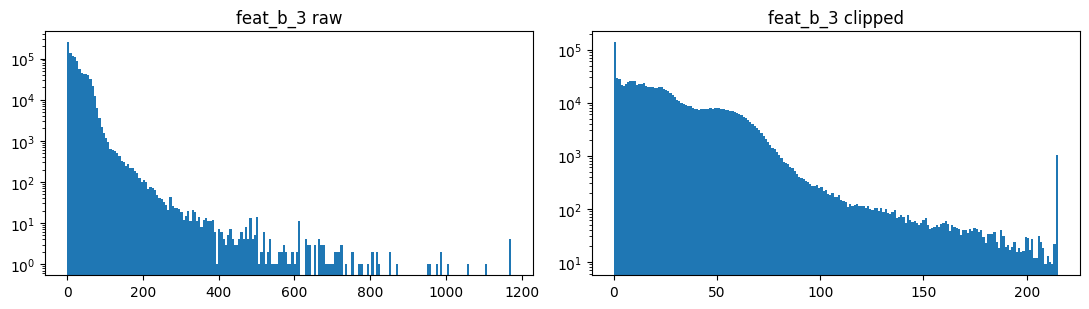

[feat_b_3] n=1,000,000 uniq=9,674 zero%=2.27% | <lo:0 >hi:1,000 | lo=0 hi=215.1 | skew=4.830 kurt=94.040
  min 5: [0. 0. 0. 0. 0.]
  max 5: [1172.7407 1172.7407 1172.7407 1172.7407 1104.5555]


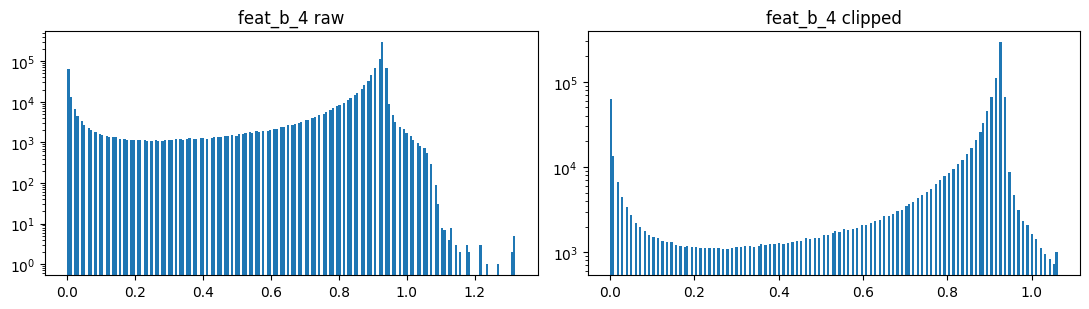

[feat_b_4] n=1,000,000 uniq=120 zero%=6.33% | <lo:0 >hi:458 | lo=0 hi=1.062 | skew=-1.875 kurt=1.951
  min 5: [0. 0. 0. 0. 0.]
  max 5: [1.3195876 1.3195876 1.3195876 1.3195876 1.3195876]


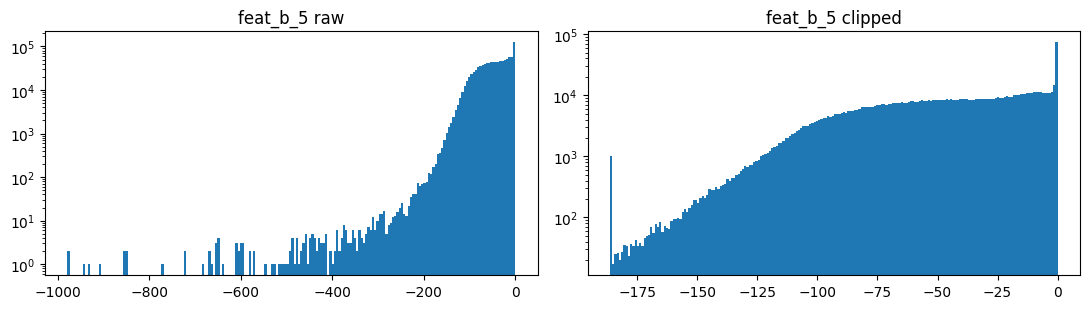

[feat_b_5] n=1,000,000 uniq=10,669 zero%=1.82% | <lo:998 >hi:0 | lo=-186.4 hi=0 | skew=-1.026 kurt=7.364
  min 5: [-979.3684 -979.3684 -941.6842 -933.8772 -906.8772]
  max 5: [0. 0. 0. 0. 0.]


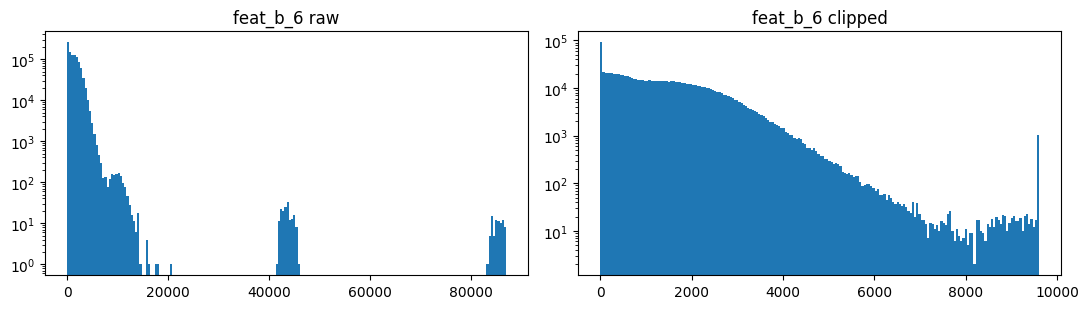

[feat_b_6] n=1,000,000 uniq=60,248 zero%=3.85% | <lo:0 >hi:1,000 | lo=0 hi=9605 | skew=19.333 kurt=961.971
  min 5: [0. 0. 0. 0. 0.]
  max 5: [86991.836 86991.836 86858.414 86846.836 86806.25 ]


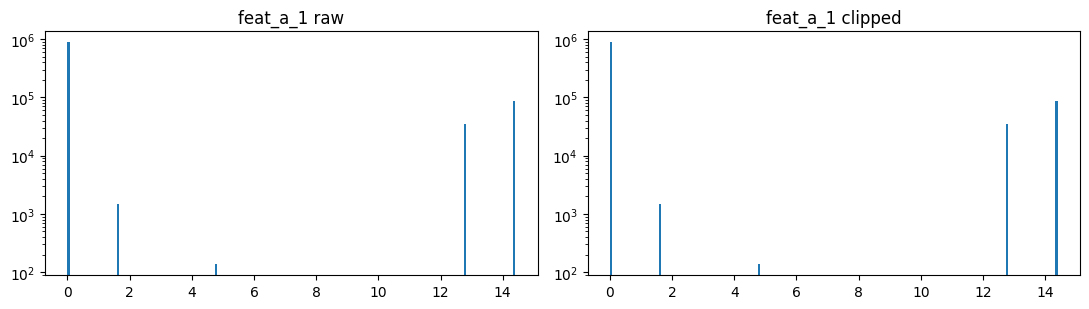

[feat_a_1] n=1,000,000 uniq=5 zero%=87.79% | <lo:0 >hi:0 | lo=0 hi=14.4 | skew=2.344 kurt=3.523
  min 5: [0. 0. 0. 0. 0.]
  max 5: [14.4 14.4 14.4 14.4 14.4]


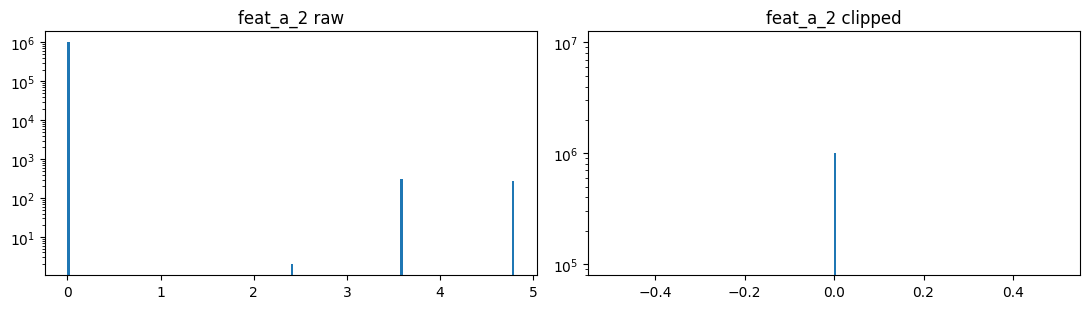

[feat_a_2] n=1,000,000 uniq=4 zero%=99.94% | <lo:0 >hi:577 | lo=0 hi=0 | skew=42.887 kurt=1871.378
  min 5: [0. 0. 0. 0. 0.]
  max 5: [4.8 4.8 4.8 4.8 4.8]


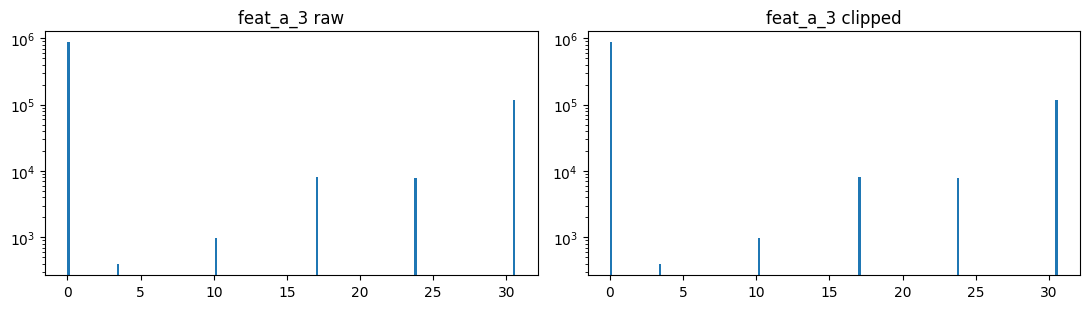

[feat_a_3] n=1,000,000 uniq=6 zero%=86.67% | <lo:0 >hi:0 | lo=0 hi=30.6 | skew=2.227 kurt=3.022
  min 5: [0. 0. 0. 0. 0.]
  max 5: [30.6 30.6 30.6 30.6 30.6]


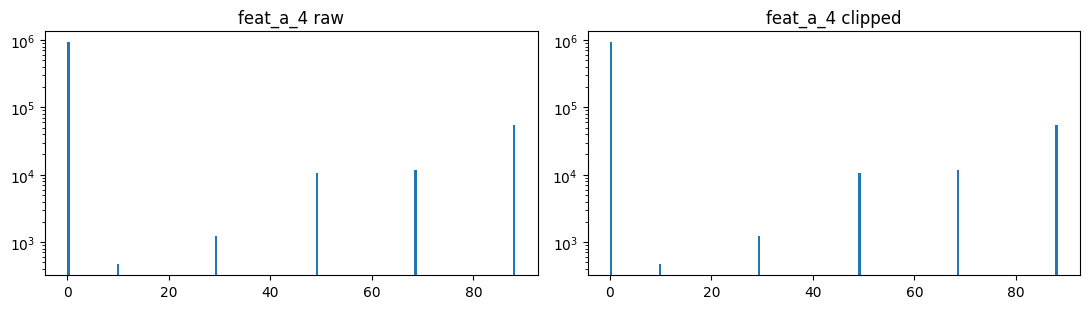

[feat_a_4] n=1,000,000 uniq=6 zero%=92.12% | <lo:0 >hi:0 | lo=0 hi=88.2 | skew=3.310 kurt=9.207
  min 5: [0. 0. 0. 0. 0.]
  max 5: [88.2 88.2 88.2 88.2 88.2]


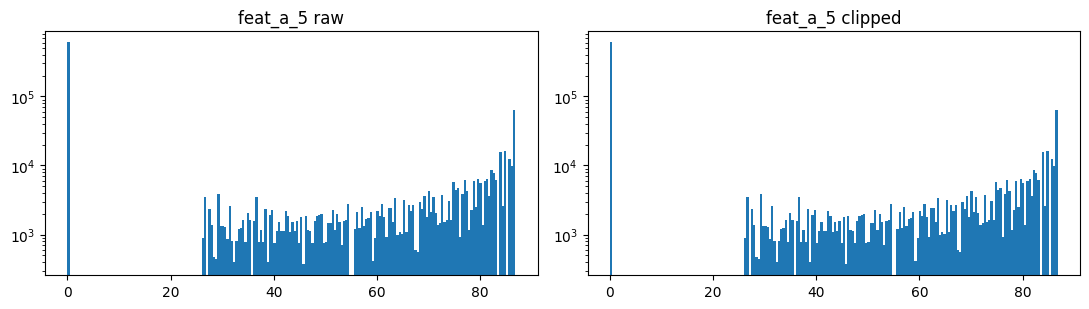

[feat_a_5] n=1,000,000 uniq=491 zero%=60.45% | <lo:0 >hi:0 | lo=0 hi=86.81 | skew=0.679 kurt=-1.352
  min 5: [0. 0. 0. 0. 0.]
  max 5: [86.8086 86.8086 86.8086 86.8086 86.8086]


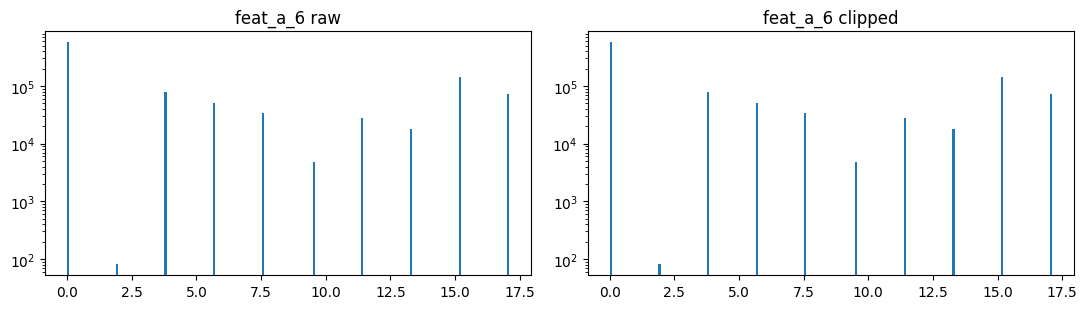

[feat_a_6] n=1,000,000 uniq=10 zero%=56.93% | <lo:0 >hi:0 | lo=0 hi=17.1 | skew=0.879 kurt=-0.951
  min 5: [0. 0. 0. 0. 0.]
  max 5: [17.1 17.1 17.1 17.1 17.1]


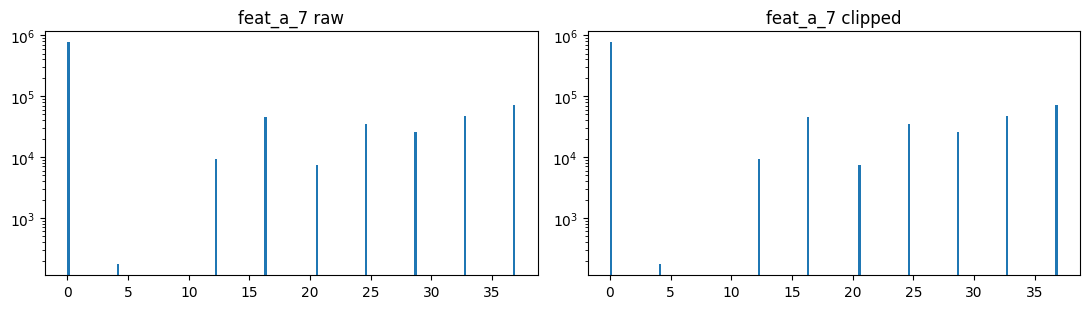

[feat_a_7] n=1,000,000 uniq=9 zero%=76.05% | <lo:0 >hi:0 | lo=0 hi=36.9 | skew=1.518 kurt=0.597
  min 5: [0. 0. 0. 0. 0.]
  max 5: [36.9 36.9 36.9 36.9 36.9]


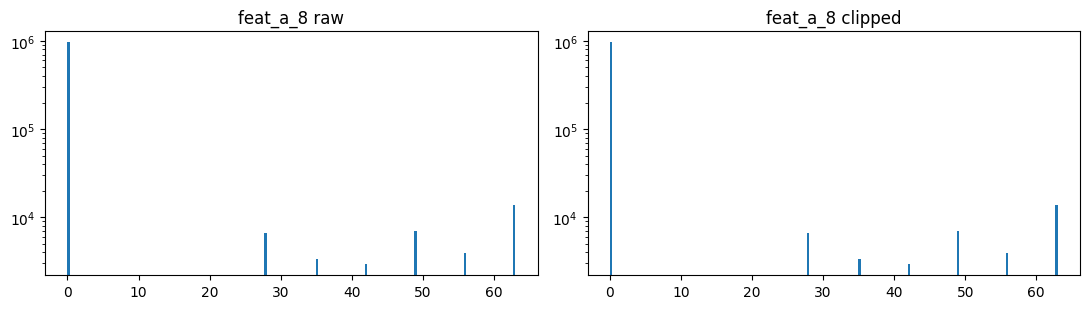

[feat_a_8] n=1,000,000 uniq=7 zero%=96.22% | <lo:0 >hi:0 | lo=0 hi=63 | skew=5.326 kurt=27.511
  min 5: [0. 0. 0. 0. 0.]
  max 5: [63. 63. 63. 63. 63.]


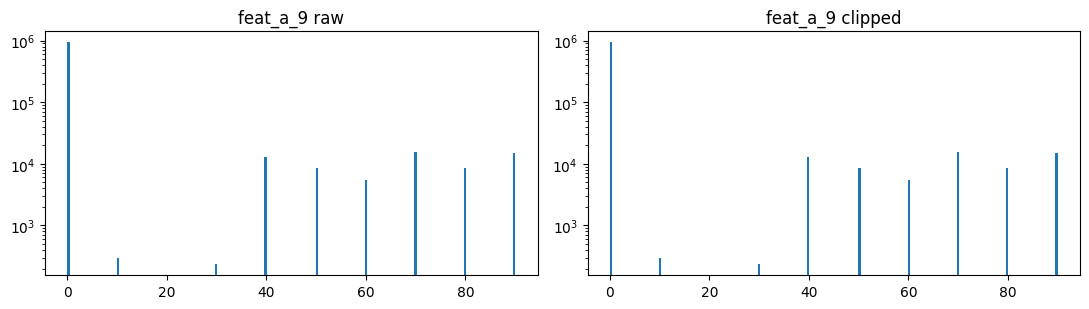

[feat_a_9] n=1,000,000 uniq=9 zero%=93.33% | <lo:0 >hi:0 | lo=0 hi=90 | skew=3.894 kurt=14.011
  min 5: [0. 0. 0. 0. 0.]
  max 5: [90. 90. 90. 90. 90.]


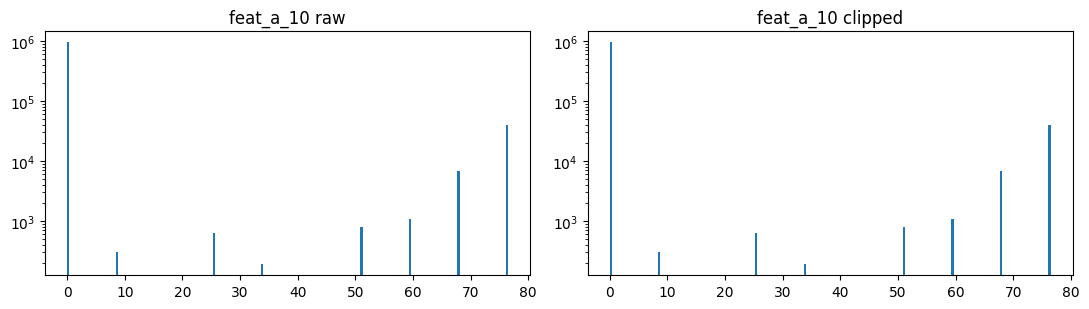

[feat_a_10] n=1,000,000 uniq=8 zero%=95.04% | <lo:0 >hi:0 | lo=0 hi=76.5 | skew=4.216 kurt=15.856
  min 5: [0. 0. 0. 0. 0.]
  max 5: [76.5 76.5 76.5 76.5 76.5]


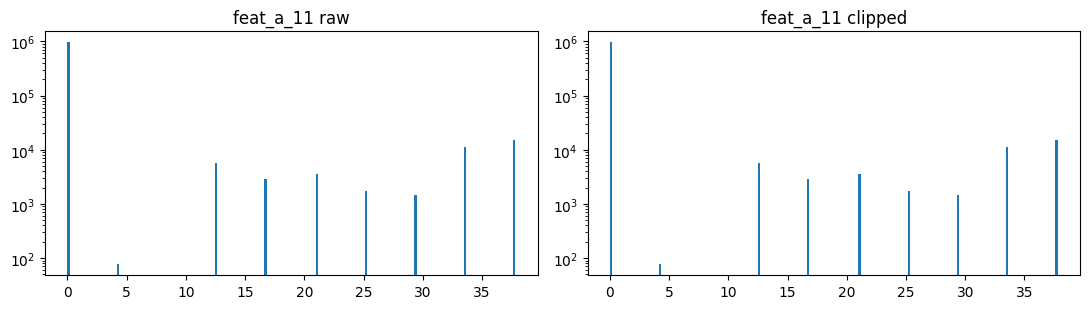

[feat_a_11] n=1,000,000 uniq=9 zero%=95.84% | <lo:0 >hi:0 | lo=0 hi=37.8 | skew=5.141 kurt=25.338
  min 5: [0. 0. 0. 0. 0.]
  max 5: [37.8 37.8 37.8 37.8 37.8]


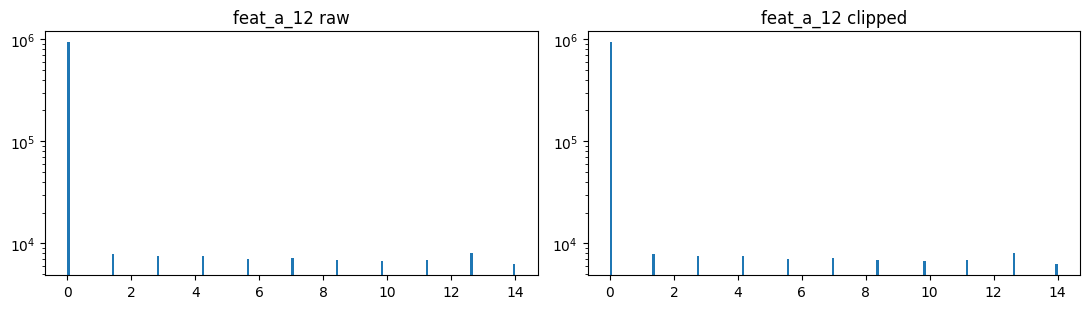

[feat_a_12] n=1,000,000 uniq=11 zero%=92.85% | <lo:0 >hi:0 | lo=0 hi=14 | skew=4.468 kurt=19.654
  min 5: [0. 0. 0. 0. 0.]
  max 5: [14. 14. 14. 14. 14.]


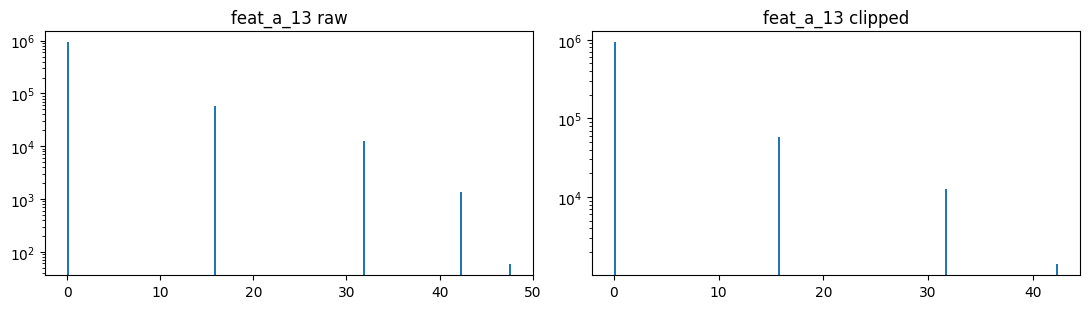

[feat_a_13] n=1,000,000 uniq=5 zero%=92.74% | <lo:0 >hi:58 | lo=0 hi=42.4 | skew=4.209 kurt=18.980
  min 5: [0. 0. 0. 0. 0.]
  max 5: [47.7 47.7 47.7 47.7 47.7]


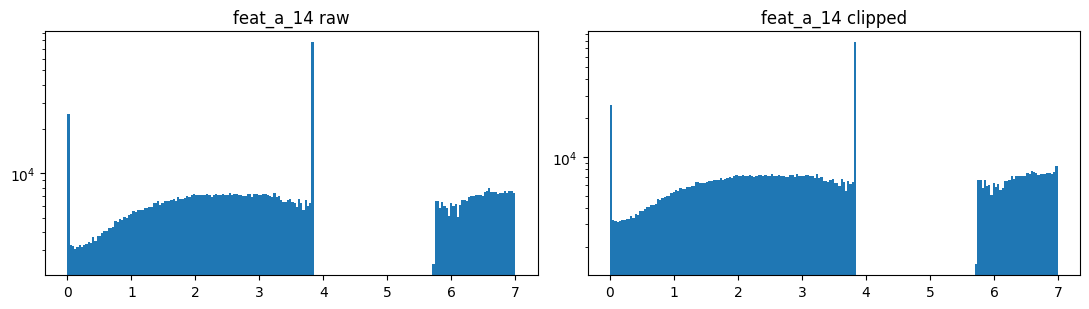

[feat_a_14] n=1,000,000 uniq=7,217 zero%=2.14% | <lo:0 >hi:967 | lo=0 hi=6.994 | skew=0.428 kurt=-0.976
  min 5: [0. 0. 0. 0. 0.]
  max 5: [7. 7. 7. 7. 7.]


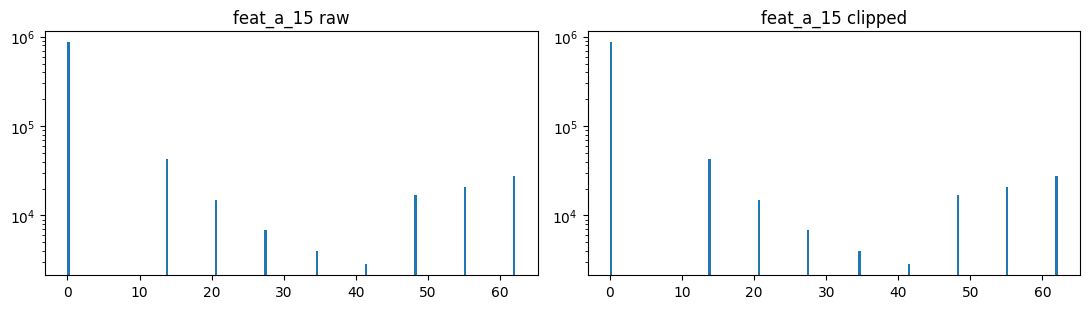

[feat_a_15] n=1,000,000 uniq=9 zero%=86.27% | <lo:0 >hi:0 | lo=0 hi=62.1 | skew=3.011 kurt=7.802
  min 5: [0. 0. 0. 0. 0.]
  max 5: [62.1 62.1 62.1 62.1 62.1]


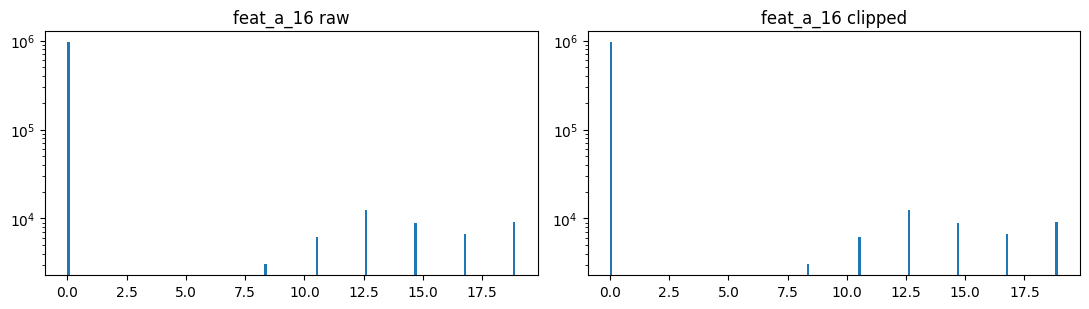

[feat_a_16] n=1,000,000 uniq=7 zero%=95.36% | <lo:0 >hi:0 | lo=0 hi=18.9 | skew=4.648 kurt=20.556
  min 5: [0. 0. 0. 0. 0.]
  max 5: [18.9 18.9 18.9 18.9 18.9]


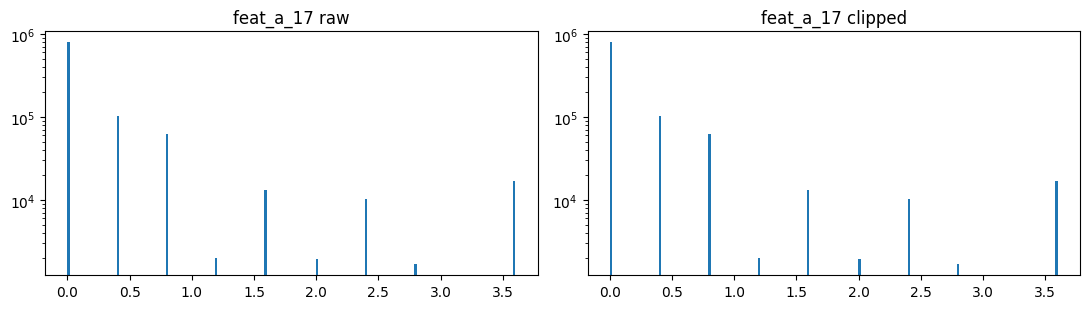

[feat_a_17] n=1,000,000 uniq=9 zero%=79.01% | <lo:0 >hi:0 | lo=0 hi=3.6 | skew=4.143 kurt=18.674
  min 5: [0. 0. 0. 0. 0.]
  max 5: [3.6 3.6 3.6 3.6 3.6]


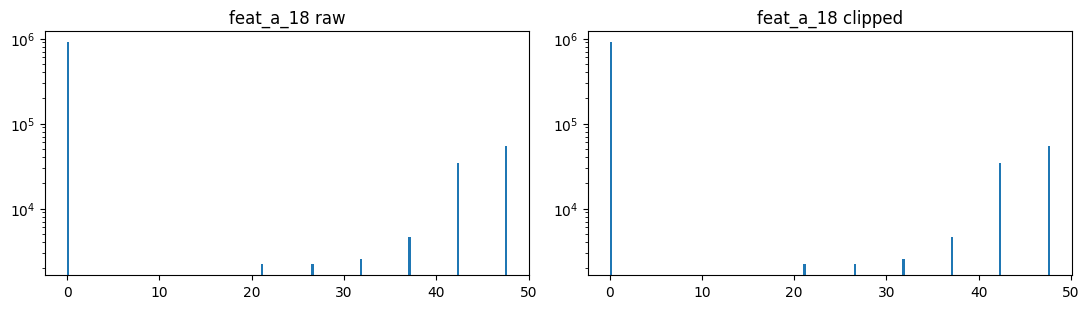

[feat_a_18] n=1,000,000 uniq=7 zero%=90.03% | <lo:0 >hi:0 | lo=0 hi=47.7 | skew=2.747 kurt=5.648
  min 5: [0. 0. 0. 0. 0.]
  max 5: [47.7 47.7 47.7 47.7 47.7]


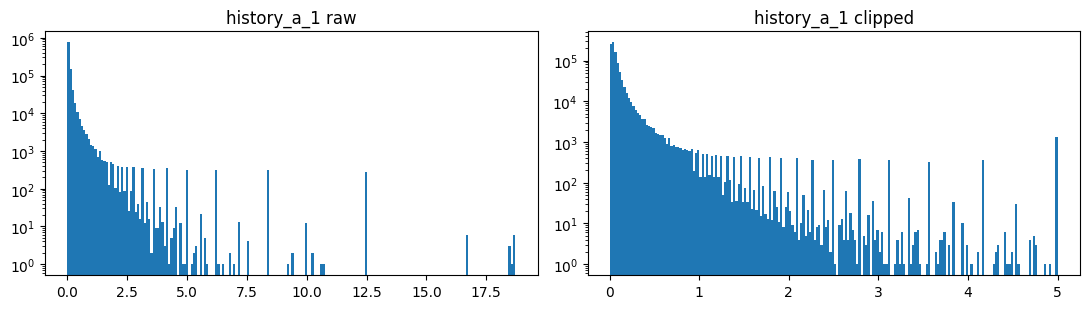

[history_a_1] n=1,000,000 uniq=59,158 zero%=0.04% | <lo:1,000 >hi:982 | lo=0.00373 hi=5 | skew=18.934 kurt=516.493
  min 5: [0. 0. 0. 0. 0.]
  max 5: [18.709814 18.709814 18.709814 18.709814 18.709814]


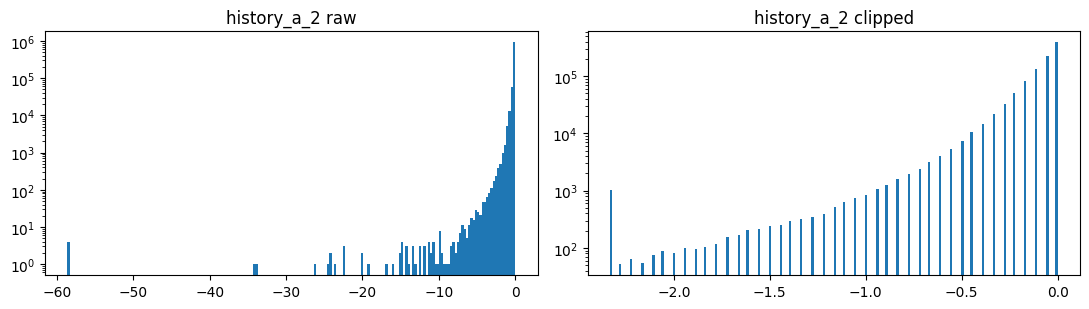

[history_a_2] n=1,000,000 uniq=179 zero%=38.78% | <lo:988 >hi:0 | lo=-2.333 hi=0 | skew=-63.589 kurt=11148.759
  min 5: [-58.61111  -58.61111  -58.61111  -58.61111  -34.055557]
  max 5: [0. 0. 0. 0. 0.]


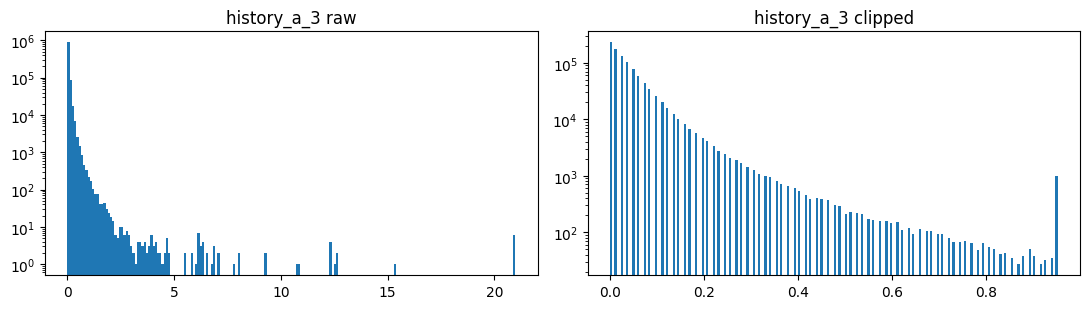

[history_a_3] n=1,000,000 uniq=277 zero%=23.06% | <lo:0 >hi:977 | lo=0 hi=0.9512 | skew=61.495 kurt=8742.040
  min 5: [0. 0. 0. 0. 0.]
  max 5: [20.975609 20.975609 20.975609 20.975609 20.975609]


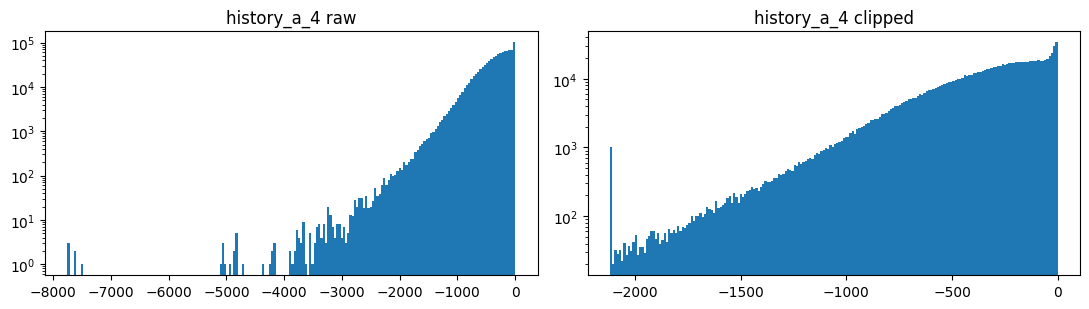

[history_a_4] n=1,000,000 uniq=13,500 zero%=0.05% | <lo:1,000 >hi:748 | lo=-2118 hi=-0.2857 | skew=-1.795 kurt=8.299
  min 5: [-7754.7144 -7754.7144 -7754.7144 -7623.     -7623.    ]
  max 5: [0. 0. 0. 0. 0.]


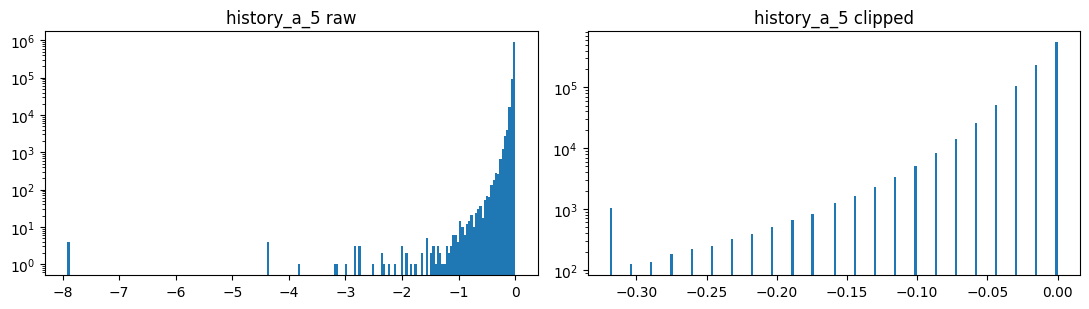

[history_a_5] n=1,000,000 uniq=112 zero%=54.39% | <lo:929 >hi:0 | lo=-0.3188 hi=0 | skew=-57.516 kurt=9545.036
  min 5: [-7.9130435 -7.9130435 -7.9130435 -7.9130435 -4.3768115]
  max 5: [0. 0. 0. 0. 0.]


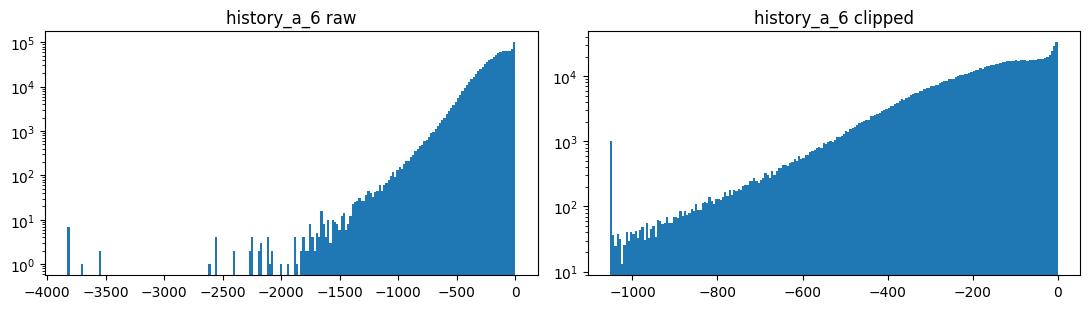

[history_a_6] n=1,000,000 uniq=7,539 zero%=0.12% | <lo:1,000 >hi:0 | lo=-1053 hi=0 | skew=-1.871 kurt=9.825
  min 5: [-3826.8572 -3826.8572 -3826.8572 -3826.8572 -3826.8572]
  max 5: [0. 0. 0. 0. 0.]


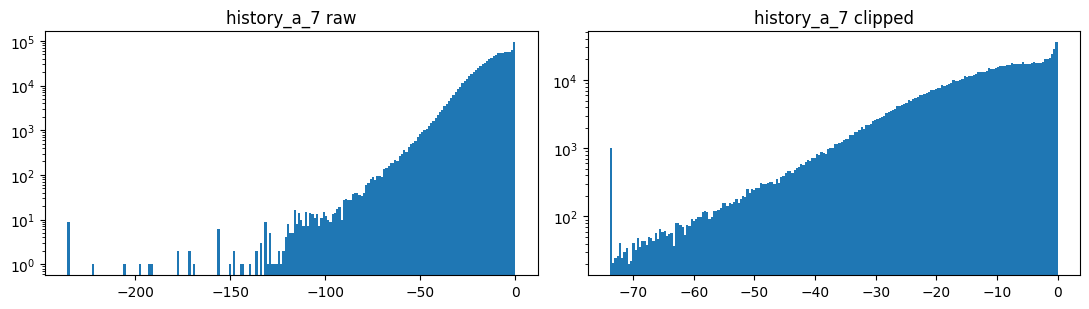

[history_a_7] n=1,000,000 uniq=4,294 zero%=0.27% | <lo:999 >hi:0 | lo=-73.83 hi=0 | skew=-1.829 kurt=8.670
  min 5: [-235.59616 -235.59616 -235.59616 -235.59616 -235.59616]
  max 5: [0. 0. 0. 0. 0.]


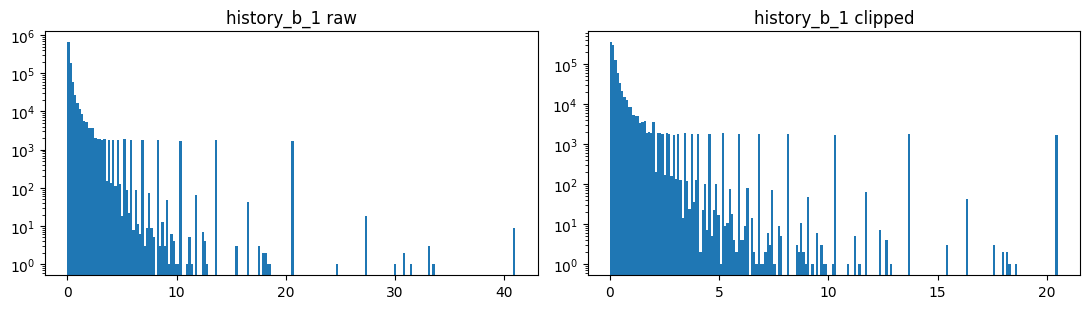

[history_b_1] n=1,000,000 uniq=20,192 zero%=0.26% | <lo:0 >hi:36 | lo=0 hi=20.5 | skew=9.742 kurt=123.518
  min 5: [0. 0. 0. 0. 0.]
  max 5: [41. 41. 41. 41. 41.]


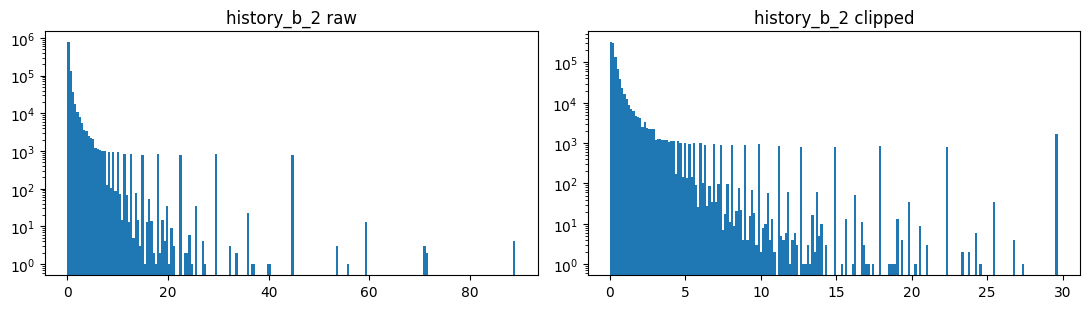

[history_b_2] n=1,000,000 uniq=38,749 zero%=0.12% | <lo:0 >hi:866 | lo=0 hi=29.67 | skew=13.385 kurt=240.731
  min 5: [0. 0. 0. 0. 0.]
  max 5: [89.  89.  89.  89.  71.2]


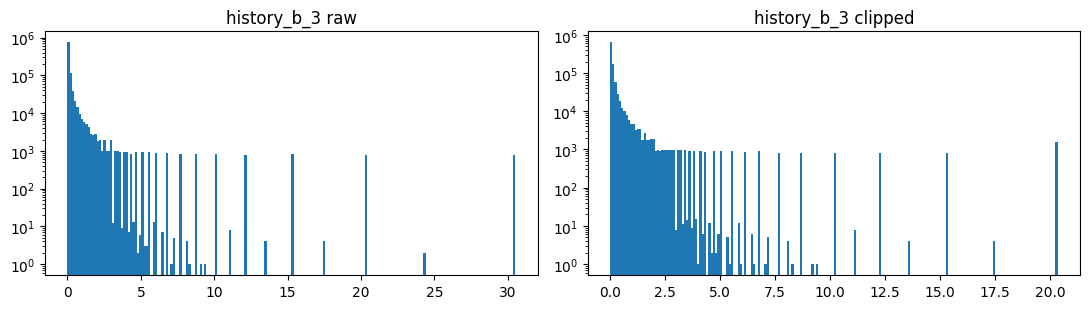

[history_b_3] n=1,000,000 uniq=14,863 zero%=0.12% | <lo:0 >hi:787 | lo=0 hi=20.33 | skew=13.839 kurt=248.291
  min 5: [0. 0. 0. 0. 0.]
  max 5: [30.5 30.5 30.5 30.5 30.5]


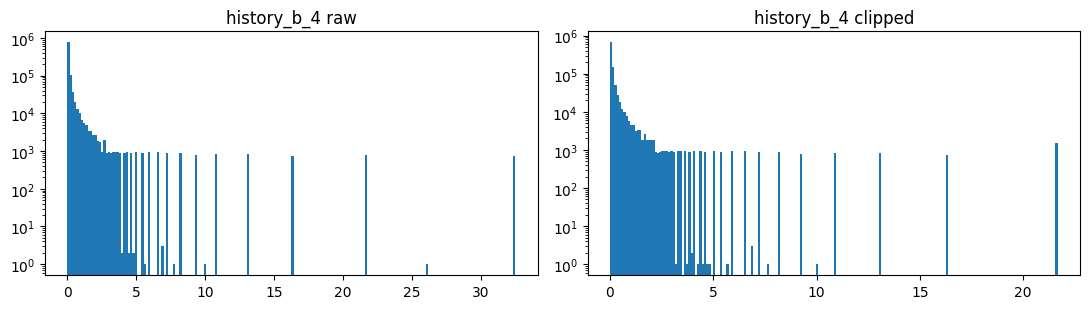

[history_b_4] n=1,000,000 uniq=9,551 zero%=0.11% | <lo:0 >hi:763 | lo=0 hi=21.67 | skew=13.864 kurt=249.551
  min 5: [0. 0. 0. 0. 0.]
  max 5: [32.5 32.5 32.5 32.5 32.5]


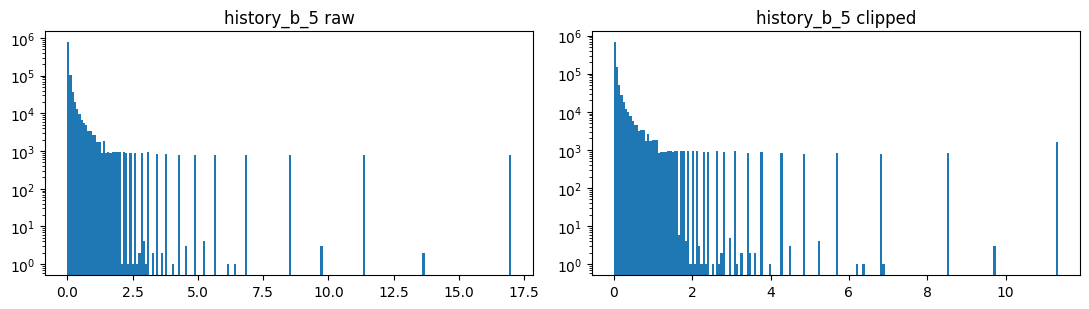

[history_b_5] n=1,000,000 uniq=10,223 zero%=0.12% | <lo:0 >hi:789 | lo=0 hi=11.33 | skew=13.925 kurt=250.287
  min 5: [0. 0. 0. 0. 0.]
  max 5: [17. 17. 17. 17. 17.]


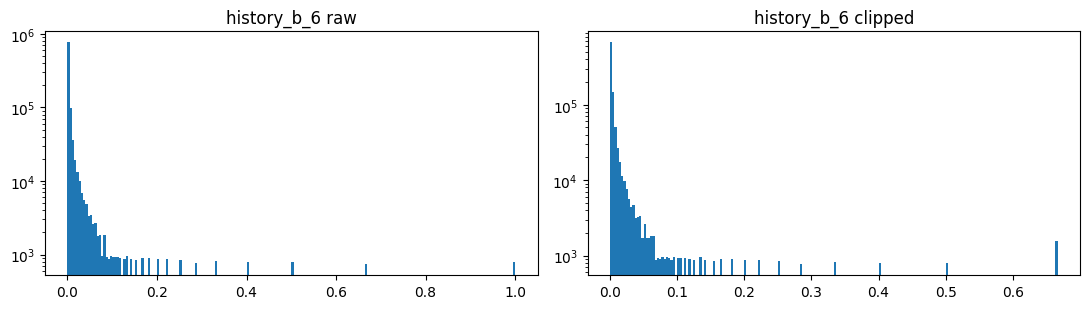

[history_b_6] n=1,000,000 uniq=6,905 zero%=0.12% | <lo:0 >hi:801 | lo=0 hi=0.6667 | skew=14.071 kurt=255.792
  min 5: [0. 0. 0. 0. 0.]
  max 5: [1. 1. 1. 1. 1.]


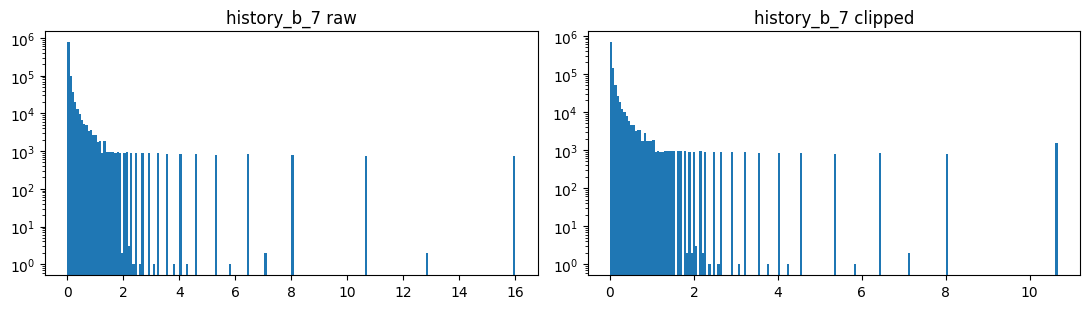

[history_b_7] n=1,000,000 uniq=8,077 zero%=0.12% | <lo:0 >hi:743 | lo=0 hi=10.67 | skew=13.956 kurt=253.582
  min 5: [0. 0. 0. 0. 0.]
  max 5: [16. 16. 16. 16. 16.]


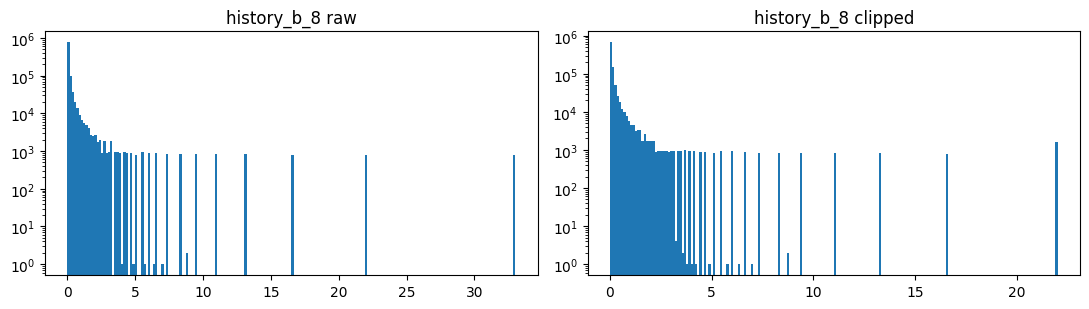

[history_b_8] n=1,000,000 uniq=8,442 zero%=0.12% | <lo:0 >hi:782 | lo=0 hi=22 | skew=13.918 kurt=250.536
  min 5: [0. 0. 0. 0. 0.]
  max 5: [33. 33. 33. 33. 33.]


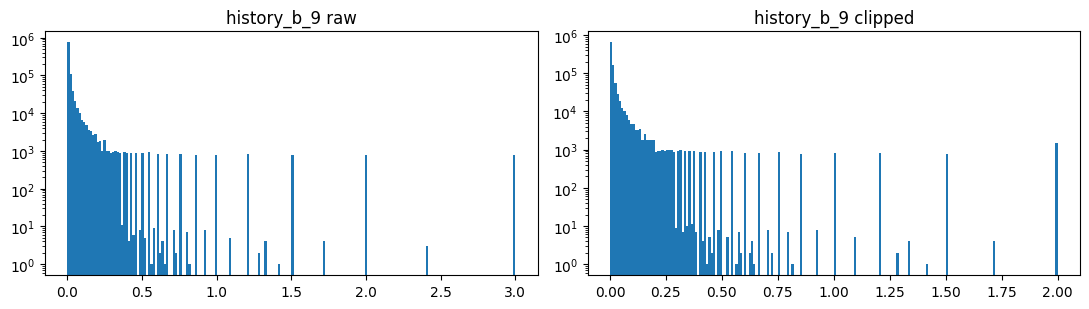

[history_b_9] n=1,000,000 uniq=13,765 zero%=0.12% | <lo:0 >hi:763 | lo=0 hi=2 | skew=13.938 kurt=252.128
  min 5: [0. 0. 0. 0. 0.]
  max 5: [3. 3. 3. 3. 3.]


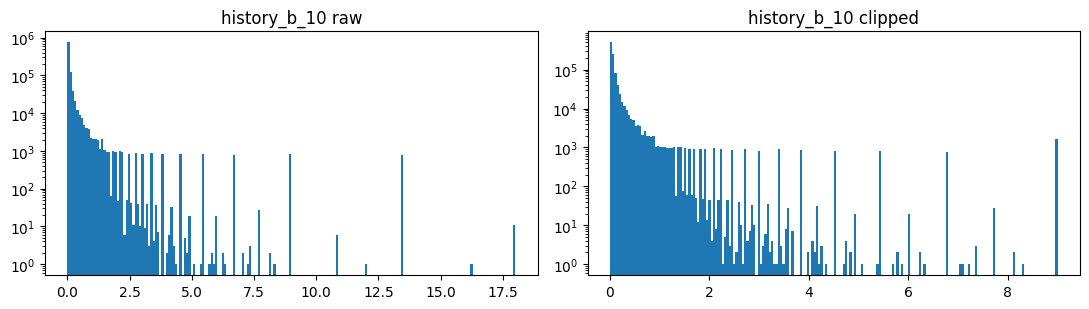

[history_b_10] n=1,000,000 uniq=25,427 zero%=0.11% | <lo:0 >hi:790 | lo=0 hi=9 | skew=13.563 kurt=240.457
  min 5: [0. 0. 0. 0. 0.]
  max 5: [18. 18. 18. 18. 18.]


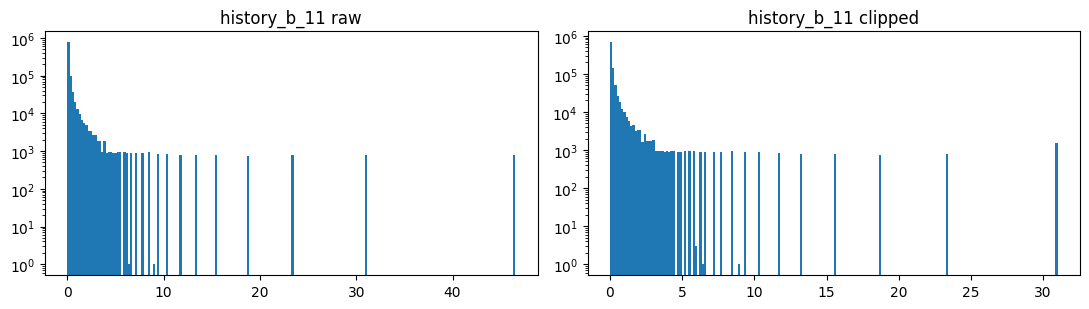

[history_b_11] n=1,000,000 uniq=7,783 zero%=0.12% | <lo:0 >hi:767 | lo=0 hi=31 | skew=14.023 kurt=254.237
  min 5: [0. 0. 0. 0. 0.]
  max 5: [46.5 46.5 46.5 46.5 46.5]


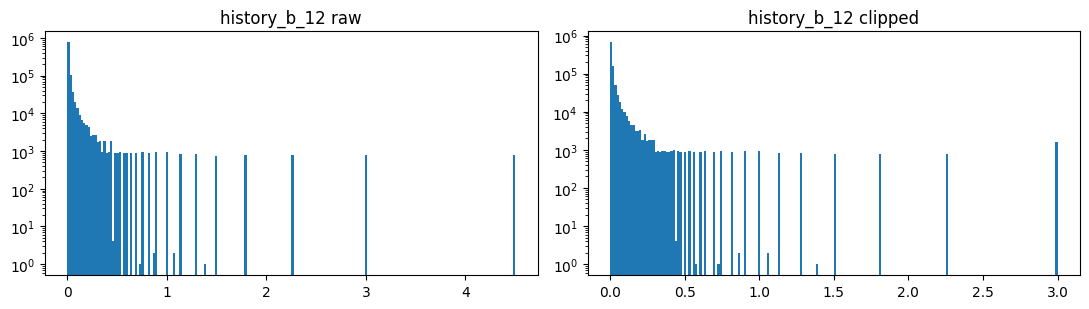

[history_b_12] n=1,000,000 uniq=11,183 zero%=0.12% | <lo:0 >hi:797 | lo=0 hi=3 | skew=13.958 kurt=251.485
  min 5: [0. 0. 0. 0. 0.]
  max 5: [4.5 4.5 4.5 4.5 4.5]


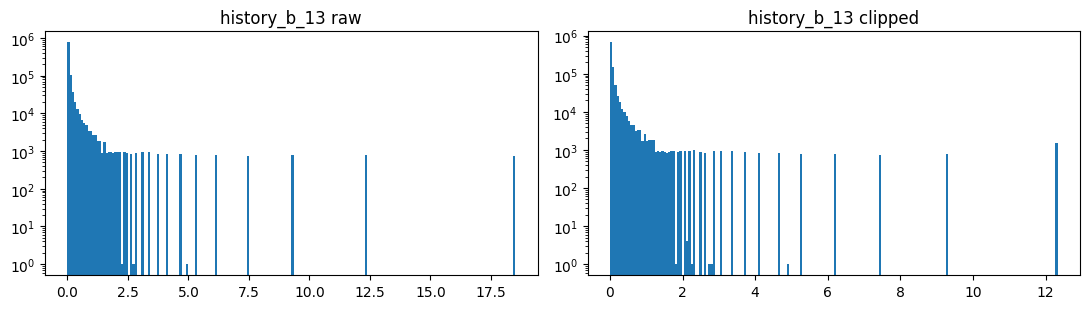

[history_b_13] n=1,000,000 uniq=10,014 zero%=0.12% | <lo:0 >hi:741 | lo=0 hi=12.33 | skew=14.041 kurt=256.150
  min 5: [0. 0. 0. 0. 0.]
  max 5: [18.5 18.5 18.5 18.5 18.5]


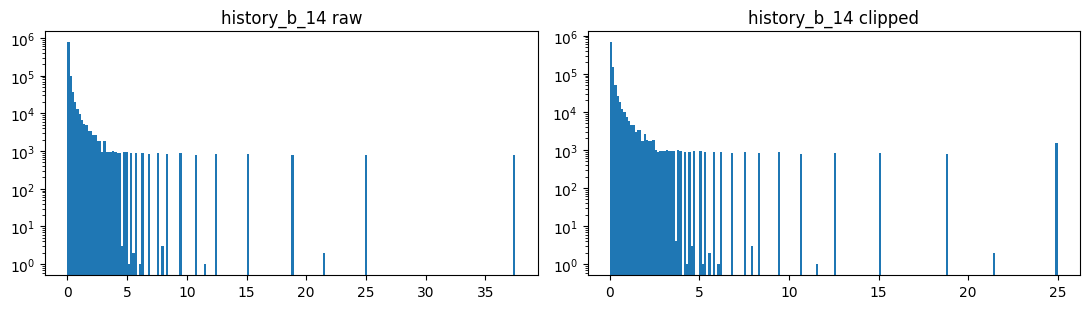

[history_b_14] n=1,000,000 uniq=8,606 zero%=0.12% | <lo:0 >hi:773 | lo=0 hi=25 | skew=13.900 kurt=250.311
  min 5: [0. 0. 0. 0. 0.]
  max 5: [37.5 37.5 37.5 37.5 37.5]


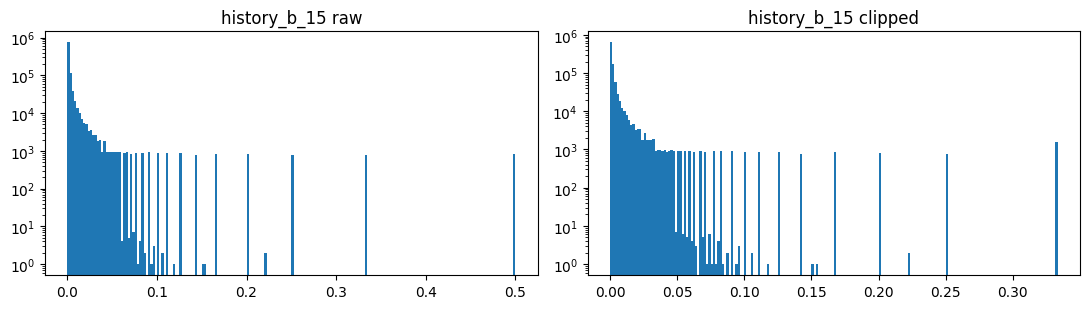

[history_b_15] n=1,000,000 uniq=15,039 zero%=0.12% | <lo:0 >hi:814 | lo=0 hi=0.3333 | skew=13.976 kurt=251.813
  min 5: [0. 0. 0. 0. 0.]
  max 5: [0.5 0.5 0.5 0.5 0.5]


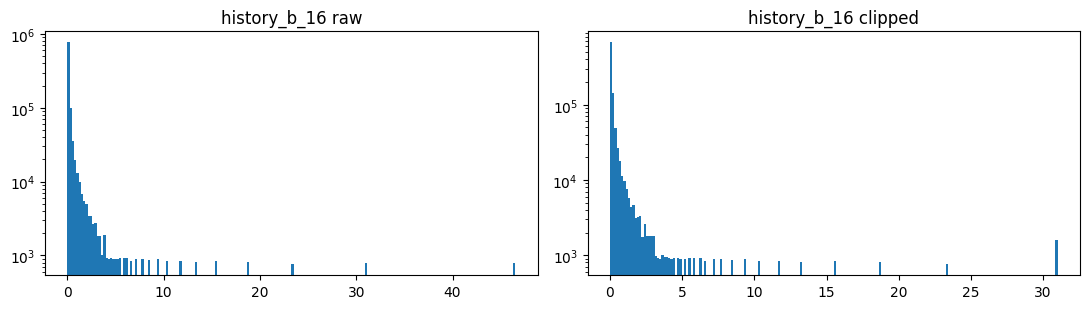

[history_b_16] n=1,000,000 uniq=5,506 zero%=0.12% | <lo:0 >hi:791 | lo=0 hi=31 | skew=13.998 kurt=253.145
  min 5: [0. 0. 0. 0. 0.]
  max 5: [46.5 46.5 46.5 46.5 46.5]


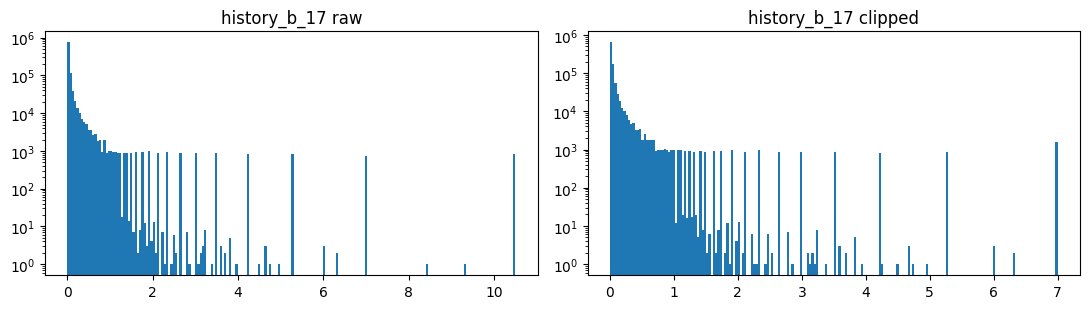

[history_b_17] n=1,000,000 uniq=14,695 zero%=0.12% | <lo:0 >hi:848 | lo=0 hi=7 | skew=13.761 kurt=244.463
  min 5: [0. 0. 0. 0. 0.]
  max 5: [10.5 10.5 10.5 10.5 10.5]


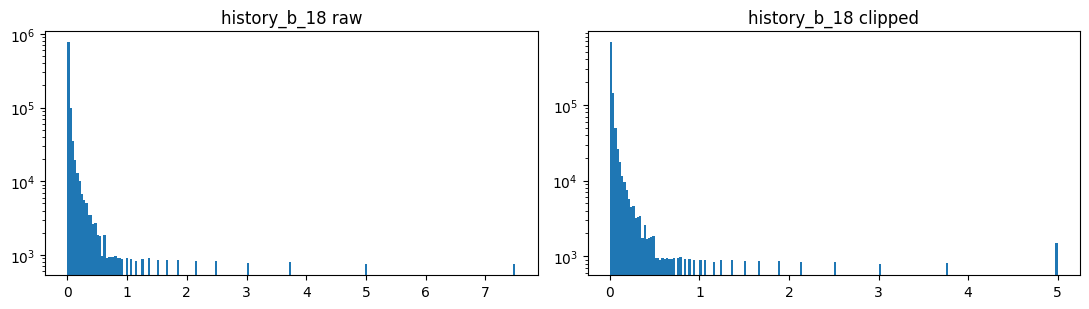

[history_b_18] n=1,000,000 uniq=5,931 zero%=0.12% | <lo:0 >hi:749 | lo=0 hi=5 | skew=13.947 kurt=252.862
  min 5: [0. 0. 0. 0. 0.]
  max 5: [7.5 7.5 7.5 7.5 7.5]


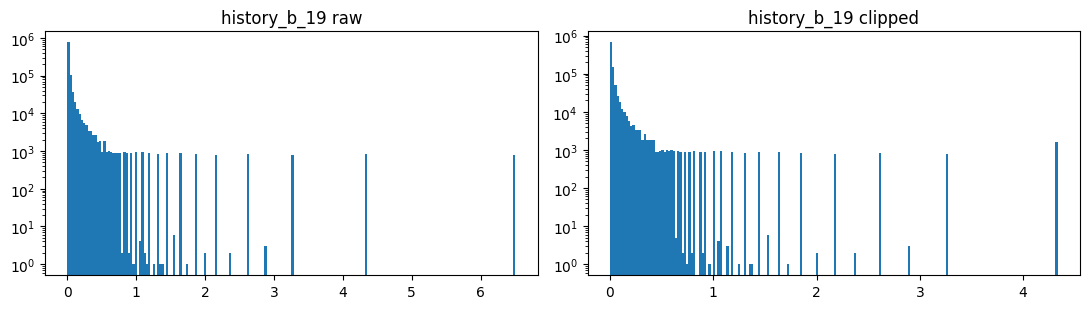

[history_b_19] n=1,000,000 uniq=9,752 zero%=0.12% | <lo:0 >hi:772 | lo=0 hi=4.333 | skew=13.846 kurt=247.676
  min 5: [0. 0. 0. 0. 0.]
  max 5: [6.5 6.5 6.5 6.5 6.5]


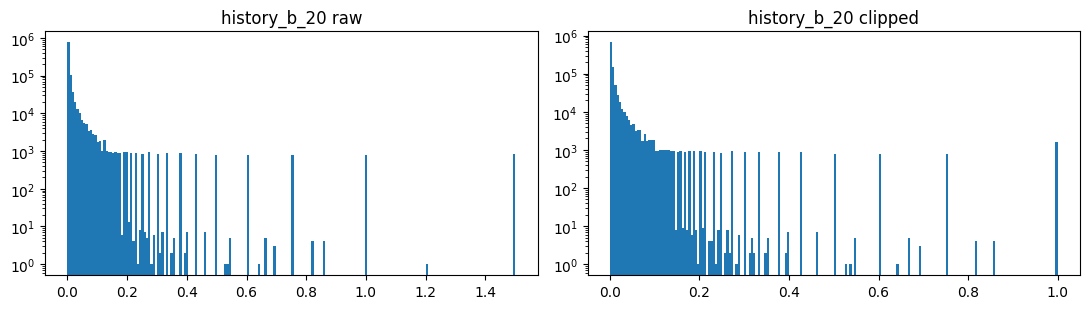

[history_b_20] n=1,000,000 uniq=10,723 zero%=0.12% | <lo:0 >hi:814 | lo=0 hi=1 | skew=13.920 kurt=250.462
  min 5: [0. 0. 0. 0. 0.]
  max 5: [1.5 1.5 1.5 1.5 1.5]


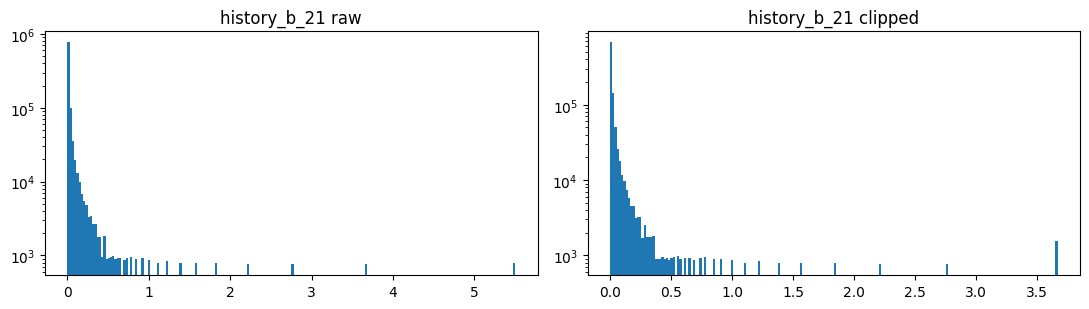

[history_b_21] n=1,000,000 uniq=5,392 zero%=0.12% | <lo:0 >hi:778 | lo=0 hi=3.667 | skew=14.121 kurt=257.809
  min 5: [0. 0. 0. 0. 0.]
  max 5: [5.5 5.5 5.5 5.5 5.5]


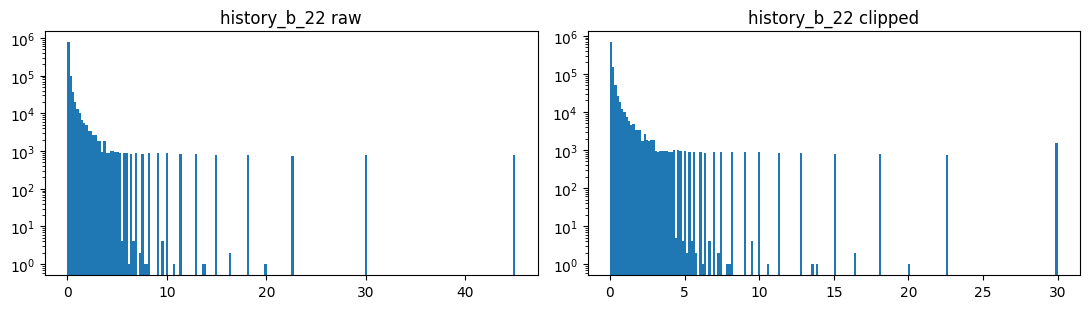

[history_b_22] n=1,000,000 uniq=8,279 zero%=0.12% | <lo:0 >hi:795 | lo=0 hi=30 | skew=14.015 kurt=254.017
  min 5: [0. 0. 0. 0. 0.]
  max 5: [45. 45. 45. 45. 45.]


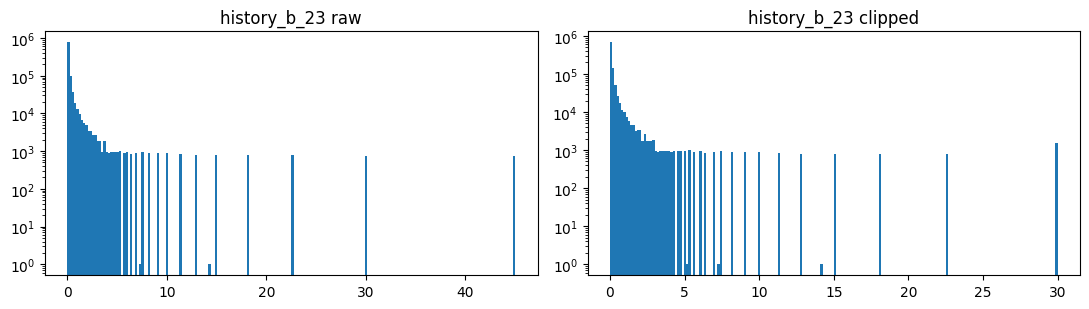

[history_b_23] n=1,000,000 uniq=6,969 zero%=0.12% | <lo:0 >hi:744 | lo=0 hi=30 | skew=13.967 kurt=254.025
  min 5: [0. 0. 0. 0. 0.]
  max 5: [45. 45. 45. 45. 45.]


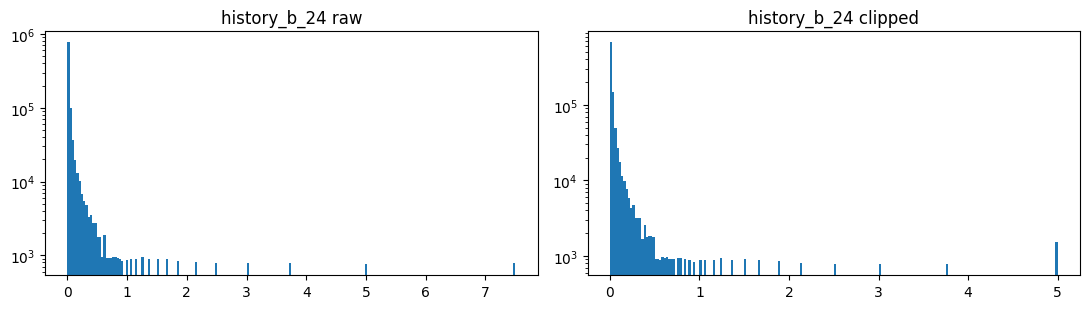

[history_b_24] n=1,000,000 uniq=7,022 zero%=0.12% | <lo:0 >hi:777 | lo=0 hi=5 | skew=14.030 kurt=254.954
  min 5: [0. 0. 0. 0. 0.]
  max 5: [7.5 7.5 7.5 7.5 7.5]


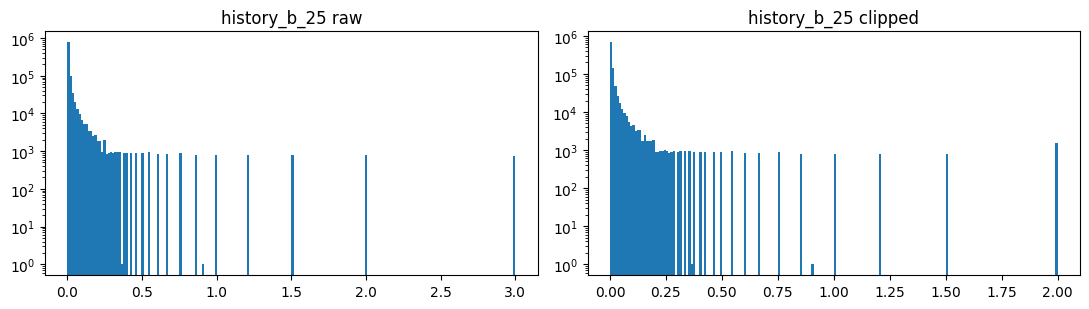

[history_b_25] n=1,000,000 uniq=5,875 zero%=0.12% | <lo:0 >hi:760 | lo=0 hi=2 | skew=13.922 kurt=251.220
  min 5: [0. 0. 0. 0. 0.]
  max 5: [3. 3. 3. 3. 3.]


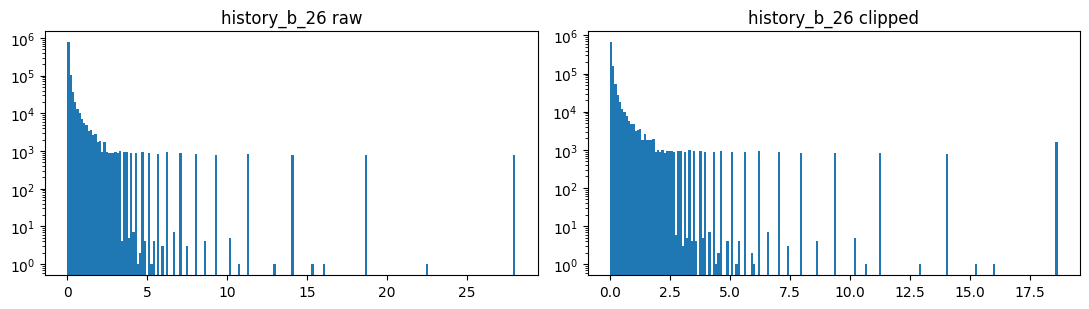

[history_b_26] n=1,000,000 uniq=11,204 zero%=0.12% | <lo:0 >hi:806 | lo=0 hi=18.67 | skew=13.875 kurt=248.716
  min 5: [0. 0. 0. 0. 0.]
  max 5: [28. 28. 28. 28. 28.]


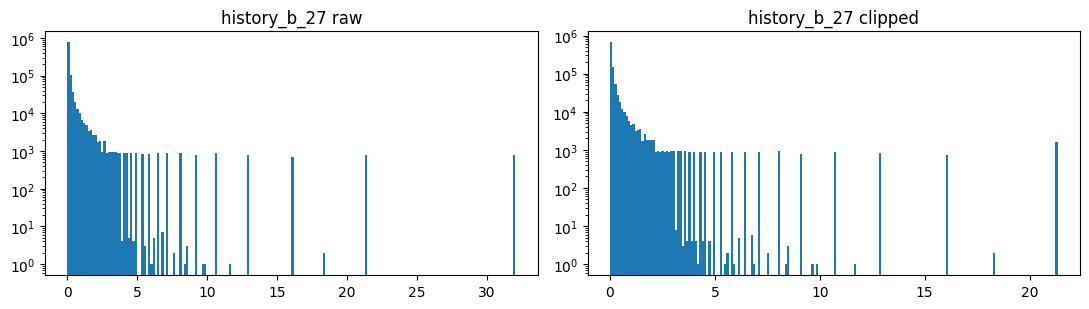

[history_b_27] n=1,000,000 uniq=11,033 zero%=0.12% | <lo:0 >hi:770 | lo=0 hi=21.33 | skew=13.945 kurt=251.844
  min 5: [0. 0. 0. 0. 0.]
  max 5: [32. 32. 32. 32. 32.]


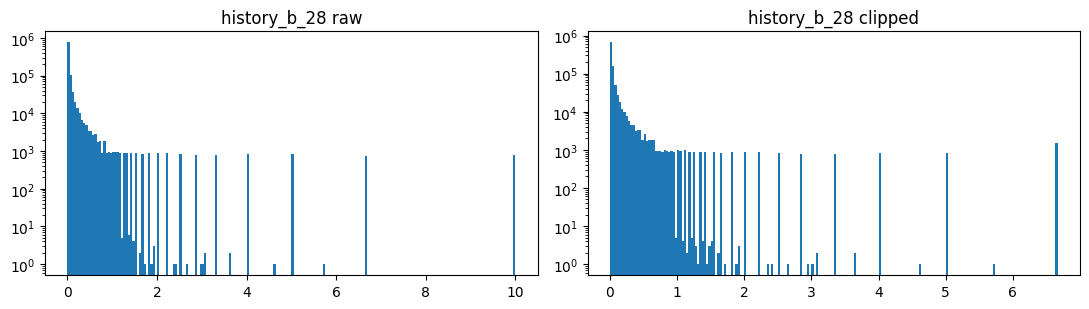

[history_b_28] n=1,000,000 uniq=10,974 zero%=0.12% | <lo:0 >hi:776 | lo=0 hi=6.667 | skew=13.996 kurt=253.650
  min 5: [0. 0. 0. 0. 0.]
  max 5: [10. 10. 10. 10. 10.]


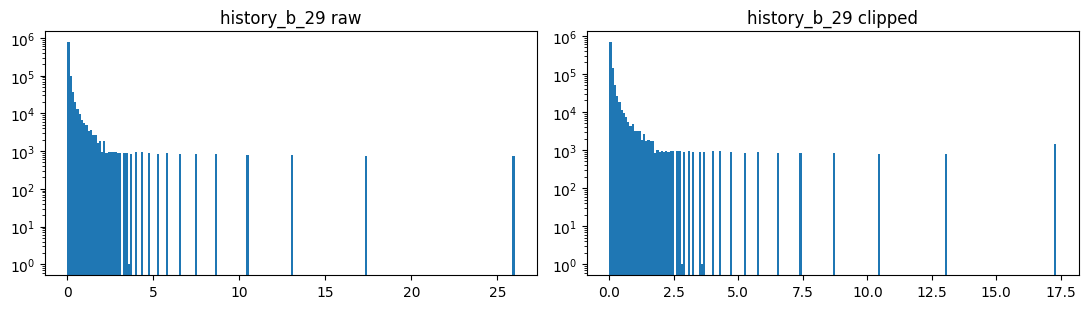

[history_b_29] n=1,000,000 uniq=7,164 zero%=0.12% | <lo:0 >hi:726 | lo=0 hi=17.33 | skew=13.944 kurt=253.798
  min 5: [0. 0. 0. 0. 0.]
  max 5: [26. 26. 26. 26. 26.]


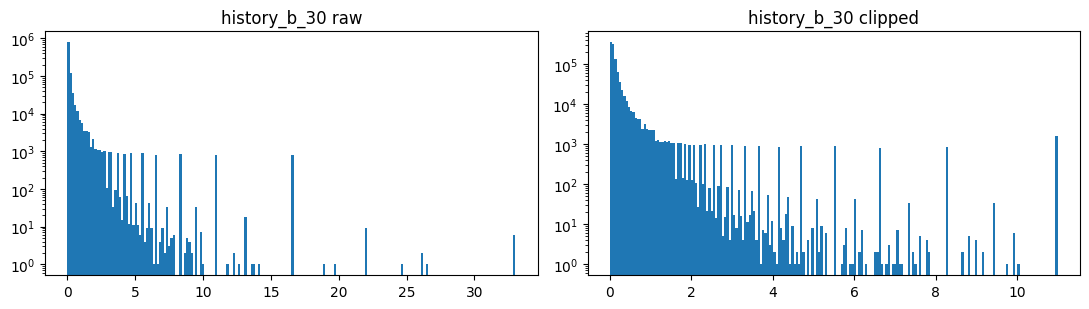

[history_b_30] n=1,000,000 uniq=36,884 zero%=0.12% | <lo:0 >hi:824 | lo=0 hi=11 | skew=13.469 kurt=246.639
  min 5: [0. 0. 0. 0. 0.]
  max 5: [33. 33. 33. 33. 33.]


In [14]:
plot_hist_scan(train_data)

### inventory_id

In [15]:
# inv_id별 노출 수, 클릭 수, 클릭률, lift 확인
KEY = 'inventory_id'
Y = 'clicked'

global_ctr = train_data[Y].mean()

table = (
    train_data.groupby(KEY)[Y]
    .agg(n='size', pos='sum')
    .reset_index()
)

table['rate'] = table['pos'] / table['n']
table['lift'] = table['rate'] / global_ctr

print(f'global ctr: {global_ctr:.6f}')

# 노출 수가 많은 inv_id 확인
display(
    table.sort_values('n', ascending=False)
    .head(5)
)

# 노출 수가 충분한 inv_id 중 lift가 높은 항목 확인
MIN_N = 100000

display(
    table[table['n'] >= MIN_N]
    .sort_values('lift', ascending=False)
    .head(5)
)

global ctr: 0.019075


,inventory_id,n,pos,rate,lift
2,2,2630473,23113,0.008787,0.460643
6,36,1518438,22973,0.015129,0.793164
7,37,1396465,41778,0.029917,1.568411
4,29,1015710,21594,0.021260,1.114566
10,42,1013762,22460,0.022155,1.161491


,inventory_id,n,pos,rate,lift
14,88,668809,25639,0.038335,2.009746
9,41,236609,8557,0.036165,1.895975
7,37,1396465,41778,0.029917,1.568411
15,91,101032,2752,0.027239,1.428012
5,31,434347,9971,0.022956,1.203495


In [16]:
# train/test 간 inv_id 차이 확인
KEY = 'inventory_id'

train_ids = set(train_data[KEY].astype(str))
test_ids = set(test_data[KEY].astype(str))

only_train = train_ids - test_ids
only_test = test_ids - train_ids
both = train_ids & test_ids

print(f'train unique inv_id: {len(train_ids):,}')
print(f'test unique inv_id: {len(test_ids):,}')
print(f'both: {len(both):,}')
print(f'only train: {len(only_train):,}')
print(f'only test: {len(only_test):,}')

train unique inv_id: 18
test unique inv_id: 18
both: 18
only train: 0
only test: 0


### seq

== seq_len describe ==
count    300000.000000
mean        530.883960
std         434.450902
min           1.000000
50%         439.000000
75%         779.000000
90%        1122.000000
95%        1345.000000
99%        1851.000000
max        6781.000000
Name: seq_len, dtype: float64


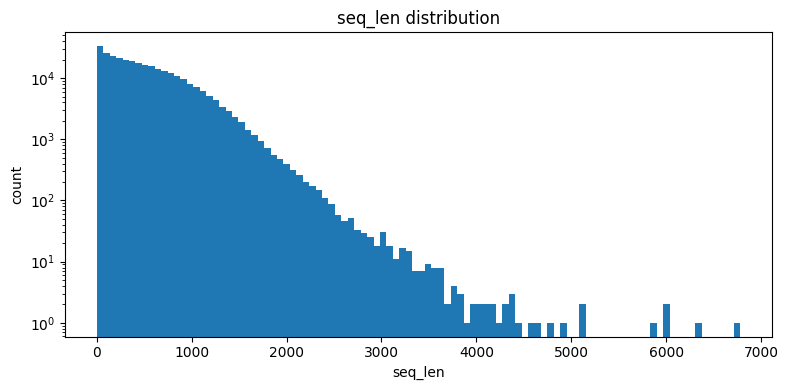


== seq_last Top10 ==


,seq_last,count,share,cum_share
0,35,143250,0.4775,0.4775
1,479,131917,0.439723,0.917223
2,519,3860,0.012867,0.93009
3,101,2569,0.008563,0.938653
4,77,2568,0.00856,0.947213
5,318,1205,0.004017,0.95123
6,57,1084,0.003613,0.954843
7,74,1018,0.003393,0.958237
8,532,852,0.00284,0.961077
9,132,729,0.00243,0.963507



== last2 Top10 ==


,last2,count,share,cum_share
0,"479,35",139833,0.46611,0.46611
1,"35,479",82969,0.276563,0.742673
2,"77,479",5802,0.01934,0.762013
3,"479,479",4072,0.013573,0.775587
4,"57,479",3988,0.013293,0.78888
5,"516,479",3546,0.01182,0.8007
6,"74,479",3487,0.011623,0.812323
7,"318,479",3067,0.010223,0.822547
8,"416,479",2366,0.007887,0.830433
9,"101,479",2059,0.006863,0.837297



== last3 Top10 ==


...

,seq_last,n,pos,ctr,lift,share
3,35,143250,2796,0.019518,1.028905,0.477500
4,479,131917,2392,0.018133,0.955857,0.439723
5,519,3860,82,0.021244,1.119848,0.012867
0,101,2569,42,0.016349,0.861823,0.008563
9,77,2568,35,0.013629,0.718465,0.008560
2,318,1205,17,0.014108,0.743694,0.004017
7,57,1084,22,0.020295,1.069858,0.003613
8,74,1018,14,0.013752,0.724958,0.003393
6,532,852,14,0.016432,0.866206,0.002840
1,132,729,10,0.013717,0.723111,0.002430



== last2 Top10 CTR ==
global ctr: 0.018970


,last2,n,pos,ctr,lift,share
4,"479,35",139833,2744,0.019623,1.034444,0.466110
2,"35,479",82969,1429,0.017223,0.907923,0.276563
9,"77,479",5802,75,0.012927,0.681422,0.019340
5,"479,479",4072,79,0.019401,1.022709,0.013573
7,"57,479",3988,93,0.023320,1.229307,0.013293
6,"516,479",3546,85,0.023971,1.263609,0.011820
8,"74,479",3487,66,0.018927,0.997757,0.011623
1,"318,479",3067,37,0.012064,0.635947,0.010223
3,"416,479",2366,60,0.025359,1.336808,0.007887
0,"101,479",2059,30,0.014570,0.768064,0.006863



== last3 Top10 CTR ==
global ctr: 0.018970


,last3,n,pos,ctr,lift,share
9,"77,479,35",28117,470,0.016716,0.881174,0.093723
7,"74,479,35",23600,417,0.017669,0.931444,0.078667
8,"77,35,479",20270,289,0.014258,0.751583,0.067567
6,"74,35,479",19771,333,0.016843,0.887868,0.065903
1,"318,479,35",16261,285,0.017527,0.923911,0.054203
0,"318,35,479",11784,194,0.016463,0.867844,0.039280
5,"57,479,35",8606,213,0.024750,1.304701,0.028687
4,"516,479,35",8402,215,0.025589,1.348927,0.028007
2,"416,479,35",5793,116,0.020024,1.055570,0.019310
3,"516,35,479",5136,120,0.023364,1.231655,0.017120


In [17]:
# seq 패턴 EDA용 샘플 생성
N = len(train_data)
S = min(300000, N)

rng = np.random.default_rng(42)
idx = rng.choice(N, size=S, replace=False)

df = train_data.iloc[idx].copy()

seq_s = df['seq'].astype('string').fillna('')
inv_s = df['inventory_id'].astype('string').fillna('')

# seq 기본 피처
df['seq_len'] = seq_s.str.count(',').add(1).astype('int16')
df['seq_last'] = seq_s.str.extract(r'([^,]+)$')[0]
df['last2'] = seq_s.str.extract(r'([^,]+,[^,]+)$')[0]
df['last3'] = seq_s.str.extract(r'([^,]+,[^,]+,[^,]+)$')[0]

df['is_last_eq_inv'] = df['seq_last'].eq(inv_s)

# seq 길이 분포 확인
print('== seq_len describe ==')
print(df['seq_len'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(df['seq_len'], bins=100)
plt.yscale('log')
plt.title('seq_len distribution')
plt.xlabel('seq_len')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# 상위 seq 패턴이 전체에서 차지하는 비율 확인
TOPK = 10

for col in ['seq_last', 'last2', 'last3']:
    vc = df[col].value_counts(dropna=True).head(TOPK)

    out = vc.reset_index()
    out.columns = [col, 'count']
    out['share'] = out['count'] / len(df)
    out['cum_share'] = out['share'].cumsum()

    print(f'\n== {col} Top{TOPK} ==')
    display(out)

# 상위 seq 패턴별 CTR / lift 확인
global_ctr = df['clicked'].mean()
TOPK = 10

for col in ['seq_last', 'last2', 'last3']:
    top_values = df[col].value_counts(dropna=True).head(TOPK).index

    table = (
        df[df[col].isin(top_values)]
        .groupby(col)['clicked']
        .agg(n='size', pos='sum')
        .reset_index()
    )

    table['ctr'] = table['pos'] / table['n']
    table['lift'] = table['ctr'] / global_ctr
    table['share'] = table['n'] / len(df)

    table = table.sort_values('n', ascending=False)

    print(f'\n== {col} Top{TOPK} CTR ==')
    print(f'global ctr: {global_ctr:.6f}')
    display(table)

In [18]:
# seq 길이 상위 1%의 CTR 확인
seq_len = train_data['seq'].astype('string').str.count(',').add(1)

p99 = int(seq_len.quantile(0.99))
top1_mask = seq_len >= p99

overall_ctr = train_data['clicked'].mean()
top1_ctr = train_data.loc[top1_mask, 'clicked'].mean()

print(f'전체 CTR: {overall_ctr:.6f} (n={len(train_data):,})')
print(f'p99 seq_len: {p99}')
print(f'seq_len >= p99 CTR: {top1_ctr:.6f} (n={top1_mask.sum():,})')
print(f'lift: {top1_ctr / overall_ctr:.3f}')

전체 CTR: 0.019075 (n=10,704,179)
p99 seq_len: 1847
seq_len >= p99 CTR: 0.018592 (n=107,090)
lift: 0.975


In [19]:
# seq 다양성 확인
N = len(train_data)
S = min(300000, N)

rng = np.random.default_rng(42)
idx = rng.choice(N, size=S, replace=False)

df = train_data.iloc[idx][['seq', 'clicked']].copy()

seq_s = df['seq'].astype('string')

df['seq_len'] = seq_s.str.count(',').add(1).astype('int32')

df['uniq_cnt'] = seq_s.map(
    lambda x: len(set(x.split(','))) if pd.notna(x) else np.nan
).astype('float32')

df['diversity_ratio'] = df['uniq_cnt'] / df['seq_len']

print('== diversity_ratio describe ==')
print(df['diversity_ratio'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

== diversity_ratio describe ==
count    300000.000000
mean          0.178893
std           0.161389
min           0.004456
10%           0.066456
25%           0.085992
50%           0.125541
75%           0.205575
90%           0.338583
95%           0.487179
99%           1.000000
max           1.000000
Name: diversity_ratio, dtype: float64


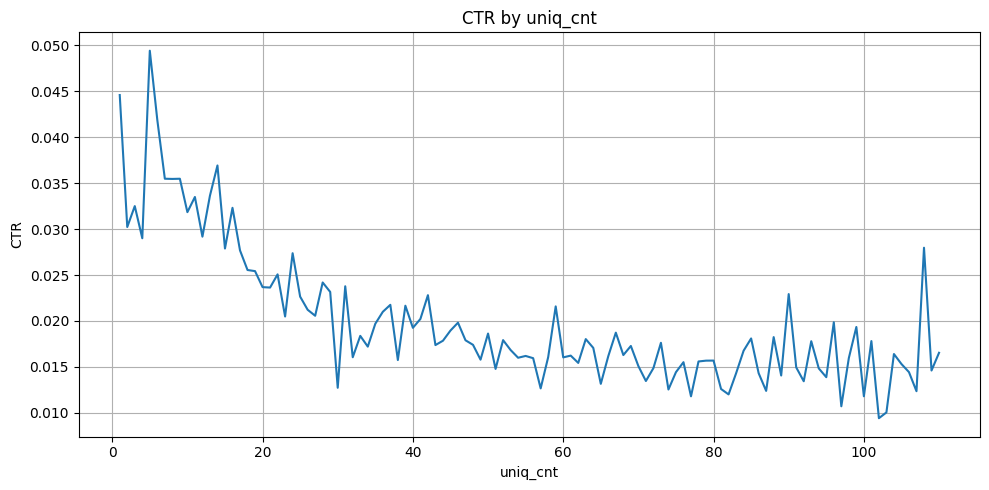

,uniq_cnt,ctr,n
0,1.0,0.044602,1973
1,2.0,0.030227,397
2,3.0,0.032505,523
3,4.0,0.029004,793
4,5.0,0.049430,1052
5,6.0,0.041874,1409
6,7.0,0.035487,1888
7,8.0,0.035464,2143
8,9.0,0.035485,2029
9,10.0,0.031847,1884


In [20]:
# uniq_cnt별 CTR 변화 확인
N = len(train_data)
S = min(300000, N)

rng = np.random.default_rng(42)
idx = rng.choice(N, size=S, replace=False)

sdf = train_data.iloc[idx][['seq', 'clicked']].copy()

seq_s = sdf['seq'].astype('string')

sdf['uniq_cnt'] = seq_s.map(
    lambda x: len(set(x.split(','))) if pd.notna(x) else np.nan
).astype('float32')

grp = (
    sdf.groupby('uniq_cnt', observed=True)['clicked']
    .agg(ctr='mean', n='size')
    .reset_index()
    .sort_values('uniq_cnt')
)

MIN_N = 100
plot_df = grp[grp['n'] >= MIN_N]

plt.figure(figsize=(10, 5))
plt.plot(plot_df['uniq_cnt'], plot_df['ctr'])
plt.xlabel('uniq_cnt')
plt.ylabel('CTR')
plt.title('CTR by uniq_cnt')
plt.grid(True)
plt.tight_layout()
plt.show()

display(plot_df.head(10))

## 종료버튼

In [ ]:
# (드라이브 쓰고 있으면 먼저 안전하게 언마운트)
try:
    from google.colab import drive
    drive.flush_and_unmount()
except Exception:
    pass

# VM 자체 제거 → 세션 끊김 + 리소스 반납
from google.colab import runtime
runtime.unassign()